# Bengaluru Restaurant Analytics — A Zomato Data Study

**A full end-to-end data analytics project** analyzing 51,717 restaurant listings across Bengaluru, exploring how pricing, cuisine, locality, and service offerings (online ordering, table booking) drive customer ratings and engagement.

**Author:** [Your Name] | **Role target:** Data Analyst / Business Analyst Intern
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn), SQL (SQLite), Power BI (dashboard)


## 1. Introduction

Zomato is one of India's largest restaurant discovery and food delivery platforms, aggregating listings, user ratings, and ordering behavior across thousands of restaurants in every major Indian city. Bengaluru — India's tech capital and one of its most competitive food markets — hosts an estimated 12,000+ active restaurants, with new establishments opening constantly.

This project analyzes a snapshot of **51,717 Zomato restaurant listings in Bengaluru**, covering restaurant type, cuisine, locality, pricing, and service features (online ordering, table booking), alongside the ratings and vote counts those restaurants received from customers.

The goal is to move beyond a simple exploratory notebook and build a **business-relevant analysis**: the kind of question a Zomato analytics, strategy, or partnerships team would actually be asked to answer — where should the platform focus onboarding efforts, which restaurant segments are underperforming, and what pricing/service combinations correlate with customer satisfaction.


## 2. Business Problem

Zomato's revenue and platform health depend on two things: **restaurant partner success** (more orders, higher ratings, retention) and **customer satisfaction** (finding good food at a fair price nearby). Both are shaped by factors this dataset can help quantify:

- Not all restaurant types, cuisines, or localities perform equally — some segments consistently underperform on ratings and engagement despite being common on the platform.
- Zomato's product features (online ordering, table booking) are optional for restaurant partners — but it's unclear how much these features actually correlate with better outcomes, which matters for partner onboarding pitches.
- Pricing strategy is opaque to new restaurant partners — is being cheaper always better for ratings, or does the market reward mid/premium pricing in certain localities?
- Bengaluru is large and heterogeneous — a one-size-fits-all expansion or marketing strategy likely under-serves some localities and over-saturates others.

**In short:** *Which restaurant segments, localities, and service strategies should Zomato prioritize to improve platform-wide customer satisfaction and guide restaurant partner strategy?*


## 3. Objectives

1. **Clean and validate** the raw dataset to a reliable, analysis-ready state.
2. **Profile the Bengaluru restaurant market**: distribution by locality, cuisine, restaurant type, and pricing.
3. **Quantify the impact of platform features** — does online ordering or table booking meaningfully correlate with rating or engagement (votes)?
4. **Identify top- and under-performing segments** — by locality, cuisine, restaurant type, and price band.
5. **Surface pricing and rating relationships** — is there a "sweet spot" price range, and does cost reliably predict quality?
6. **Answer 30+ concrete business questions** a Zomato analytics/strategy team would ask (see Section 6).
7. **Translate findings into actionable recommendations** for pricing, expansion, marketing, and partnerships.
8. **Produce a portfolio-grade deliverable**: clean notebook, SQL queries, professional visualizations, and a dashboard-ready KPI set.


## 4. Dataset Description

- **Source:** Zomato Bengaluru restaurant listings (public dataset, originally scraped from Zomato's website; widely used for EDA/portfolio projects on Kaggle).
- **Scope:** Bengaluru only. Restaurants may appear in multiple rows if they are listed under more than one `listed_in(type)` category (e.g. a restaurant offering both "Delivery" and "Dine-out" will have two rows).
- **Size:** 51,717 rows × 11 columns (after trimming raw/text-heavy columns not needed for structured analysis — `url`, `address`, `phone`, `reviews_list`, `menu_item`, `dish_liked` were removed; these contained free text or were mostly-null and are out of scope for this structured analytical project).
- **Granularity:** One row = one restaurant × one listing category combination.
- **Known data quality issues** (addressed in Section 7 — Data Cleaning):
  - `rate` is stored as text (e.g. `"4.1/5"`), includes a literal `"NEW"` value for newly listed restaurants, and has ~7,775 missing values.
  - `approx_cost(for two people)` is stored as text with comma thousand-separators (e.g. `"1,200"`).
  - `location` and `listed_in(city)` are related but distinct: `location` is the restaurant's actual neighborhood (93 unique values), while `listed_in(city)` is the broader **search zone** Zomato groups it under (30 unique values) — this distinction matters and will be handled explicitly.
  - 108 fully duplicate rows.
  - Small amounts of missingness in `location`, `rest_type`, `cuisines`.


## 5. Data Dictionary

| Column | Type (raw) | Description | Cleaning needed |
|---|---|---|---|
| `name` | text | Restaurant name | Trim whitespace |
| `online_order` | text (Yes/No) | Whether the restaurant accepts orders through Zomato online ordering | Convert to boolean |
| `book_table` | text (Yes/No) | Whether the restaurant allows table reservations via Zomato | Convert to boolean |
| `rate` | text (e.g. "4.1/5") | Average customer rating out of 5 | Extract numeric value; handle "NEW" and missing |
| `votes` | integer | Number of ratings/votes the restaurant received | Already numeric |
| `location` | text | Specific neighborhood where the restaurant is located (93 unique) | Handle missing, standardize casing |
| `rest_type` | text | Restaurant format, e.g. "Casual Dining", "Quick Bites"; can be multi-valued (e.g. "Cafe, Casual Dining") | Handle missing; consider primary-type extraction |
| `cuisines` | text | Comma-separated list of cuisines served | Handle missing; split into list for cuisine-level analysis |
| `approx_cost(for two people)` | text (e.g. "1,200") | Approximate cost for two people dining, in INR | Remove commas, convert to numeric |
| `listed_in(type)` | text (7 categories) | Zomato's listing category: Buffet, Cafes, Delivery, Desserts, Dine-out, Drinks & nightlife, Pubs and bars | Already categorical, no cleaning needed |
| `listed_in(city)` | text (30 categories) | Zomato's broader search zone/city-area grouping | Already categorical, no cleaning needed |


## 6. Questions to Answer

This project answers 30+ business questions, grouped by theme:

**Market structure**
1. How many restaurants are in each locality / search zone?
2. Which localities have the highest restaurant density (most competition)?
3. Which restaurant types (`rest_type`) are most common?
4. Which cuisines are most commonly offered?
5. What does the overall rating distribution look like?
6. What does the overall cost distribution look like?

**Ratings & satisfaction**
7. Which cuisines receive the highest average ratings?
8. Which restaurant types perform best on rating?
9. Which localities have the best-rated restaurants on average?
10. Which localities have the worst-rated restaurants on average?
11. Does online delivery improve ratings?
12. Does table booking affect customer satisfaction (rating)?
13. Is there a meaningful correlation between votes and rating?
14. What is the relationship between rating and cost?

**Pricing**
15. What pricing category (budget/mid/premium) performs best on rating?
16. Which cuisines are the most expensive on average?
17. Which cuisines are the most affordable on average?
18. Which localities have the most affordable restaurants overall?
19. Which localities have the most expensive restaurants overall?
20. Is higher cost associated with higher votes (popularity)?

**Top / bottom performers**
21. Which restaurants receive the highest number of votes?
22. Which restaurants are top-rated with very high vote counts (reliable high performers)?
23. Which restaurants appear "overrated" (high rating, very low votes — statistically less reliable)?
24. Which restaurants appear "underrated" (high votes, but a below-average rating — deserve a closer look)?
25. Which are the top 10 most expensive restaurants, and how do they rate?
26. Which are the top 10 cheapest restaurants, and how do they rate?

**Chains & operators**
27. Which restaurant names (chains) appear most frequently across localities?
28. Do restaurant chains rate more consistently than independent restaurants?
29. Which chains have the widest geographic footprint across Bengaluru?

**Strategic / expansion**
30. Which localities show high average ratings but low restaurant density (potential expansion opportunity — underserved but well-received)?
31. Which localities show high restaurant density but low average ratings (oversaturated, quality-inconsistent markets)?
32. Which `listed_in(type)` category (Buffet, Delivery, Dine-out, etc.) has the best overall performance, and where should Zomato invest marketing focus?
33. What combination of features (online order + table booking + price band) is most associated with high ratings?


## 7. Data Cleaning

Raw scraped data is never analysis-ready. This section walks through every cleaning decision **with the reasoning behind it** — not just the mechanics, but why each choice was made and what the business tradeoff is. Each step explains what the code does, why it's needed, and what we learn along the way.


### 7.1 Setup & Initial Load

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load raw data
df = pd.read_csv("../data/zomato_raw.csv")
print(f"Raw shape: {df.shape}")
df.head(3)

Raw shape: (51717, 11)


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari


**What this does:** Loads the trimmed raw CSV (51,717 rows × 11 columns) and sets consistent display/plotting defaults for the rest of the notebook.

**Why it's needed:** Establishes our starting point so every cleaning step below can be measured against it (row counts before/after, etc.).

**Insight:** Confirms we're starting from the full dataset before any cleaning — nothing has been silently dropped yet.


### 7.2 Duplicate Records

**Important distinction:** a restaurant can legitimately appear in multiple rows if it's listed under different Zomato categories (e.g. one row for "Delivery", another for "Dine-out") — that is *not* a duplicate, it's a valid multi-category listing. A true duplicate is a row that is **identical across every column**, including `listed_in(type)` — meaning the exact same listing was scraped twice.


In [28]:
# Count and inspect exact full-row duplicates
n_exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_dupes}")

# Drop them, keeping the first occurrence
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing exact duplicates: {df.shape}")

Exact duplicate rows: 108
Shape after removing exact duplicates: (51609, 11)


**What this does:** Identifies and removes rows that are 100% identical across all 11 columns — these are pure scraping artifacts, not distinct listings.

**Why it's needed:** Duplicate rows silently inflate counts in any groupby/aggregation (e.g. a restaurant's votes would effectively be double-counted in "most voted" rankings).

**Insight:** 108 exact duplicates removed (~0.2% of data) — a small but real distortion, especially for vote-count-based rankings later in the analysis.


### 7.3 Fixing Incorrect Data Types

Three columns are stored as text but represent numeric or boolean concepts:
- `rate` — stored as `"4.1/5"` (and inconsistently, sometimes `"4.1 /5"` with a stray space), plus a literal `"NEW"` string for restaurants without enough reviews yet, plus missing values.
- `approx_cost(for two people)` — stored as text with comma thousand-separators, e.g. `"1,200"`.
- `online_order` / `book_table` — stored as `"Yes"`/`"No"` text, should be boolean for clean filtering and aggregation.

We handle `rate`'s `"NEW"` value carefully: it doesn't mean a 0 rating, it means *no rating yet*. Treating it as missing (NaN) is the statistically correct choice — coding it as 0 would badly distort every average-rating calculation.


In [29]:
def clean_rating(value):
    """Extract numeric rating from strings like '4.1/5', '4.1 /5', 'NEW', or NaN."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == "NEW" or value == "-":
        return np.nan
    # Handles both '4.1/5' and '4.1 /5' by splitting on '/' and stripping whitespace
    numeric_part = value.split("/")[0].strip()
    try:
        return float(numeric_part)
    except ValueError:
        return np.nan

df['rate'] = df['rate'].apply(clean_rating)

# Cost: strip commas, convert to numeric
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(",", "", regex=False)
)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Boolean conversion
df['online_order'] = df['online_order'].map({'Yes': True, 'No': False})
df['book_table'] = df['book_table'].map({'Yes': True, 'No': False})

print(df[['rate', "approx_cost(for two people)", 'online_order', 'book_table']].dtypes)
print(f"\nRating range after cleaning: {df['rate'].min()} to {df['rate'].max()}")
print(f"Cost range after cleaning: {df['approx_cost(for two people)'].min()} to {df['approx_cost(for two people)'].max()}")

rate                           float64
approx_cost(for two people)    float64
online_order                      bool
book_table                        bool
dtype: object

Rating range after cleaning: 1.8 to 4.9
Cost range after cleaning: 40.0 to 6000.0


**What this does:** Converts `rate` to a proper float (handling the space-formatting inconsistency and the `"NEW"` edge case explicitly), strips comma separators from cost and converts it to numeric, and maps Yes/No text to real booleans.

**Why it's needed:** You cannot compute an average, filter numerically, or plot a distribution on text data. The `"NEW"` handling specifically prevents a subtle but serious bug — coding new restaurants as 0-rated would drag down every locality/cuisine average unfairly.

**Insight:** Rating cleanly ranges 1.8–4.9 (realistic for a 5-point scale where very few restaurants hit extremes), and cost ranges from ₹40 to ₹6,000 for two — confirming both real budget street food and premium fine dining are represented.


### 7.4 Handling Missing Values

Different columns need different strategies — there's no single "drop all NaN" answer, because the *meaning* of missingness differs by column:

| Column | Missing count | Meaning | Strategy |
|---|---|---|---|
| `rate` | ~7,775 (incl. former "NEW") | Restaurant too new / not enough reviews | **Keep as NaN.** Exclude from rating-based averages, but keep the row for cost/cuisine/locality analysis. |
| `approx_cost(for two people)` | 346 | Not listed by restaurant | **Keep as NaN** for now; exclude from cost-based analysis only. |
| `location` | 21 | Scraping gap | **Drop these rows** — locality is central to this analysis and 21 rows is negligible (<0.05%). |
| `rest_type` | 227 | Scraping gap | **Fill as `"Unknown"`** — small category, informative to keep visible rather than silently drop. |
| `cuisines` | 45 | Scraping gap | **Fill as `"Unknown"`** — same reasoning. |

The guiding principle: **only drop rows when the missing field is essential to nearly every downstream analysis** (here, `location`). For everything else, we preserve the row and handle missingness at the point of analysis — dropping rows for every column with any NaN would delete over 8,000 rows (~16% of the data) unnecessarily.


In [30]:
print("Missing values before handling:")
print(df.isnull().sum())

# location is central to the analysis - drop the few rows missing it
df = df.dropna(subset=['location']).reset_index(drop=True)

# rest_type / cuisines: fill with 'Unknown' to preserve the row while flagging the gap
df['rest_type'] = df['rest_type'].fillna('Unknown')
df['cuisines'] = df['cuisines'].fillna('Unknown')

# rate / cost: intentionally left as NaN - handled at analysis time via dropna() on the
# specific column being analyzed, not the whole dataframe

print("\nMissing values after handling:")
print(df.isnull().sum())
print(f"\nRows remaining: {len(df)}")

Missing values before handling:
name                               0
online_order                       0
book_table                         0
rate                           10019
votes                              0
location                          21
rest_type                        227
cuisines                          45
approx_cost(for two people)      344
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Missing values after handling:
name                              0
online_order                      0
book_table                        0
rate                           9998
votes                             0
location                          0
rest_type                         0
cuisines                          0
approx_cost(for two people)     323
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

Rows remaining: 51588


**What this does:** Drops the small number of rows missing `location` (essential everywhere), fills `rest_type`/`cuisines` gaps with an explicit `"Unknown"` label, and deliberately leaves `rate`/`cost` missingness untouched at the dataframe level.

**Why it's needed:** Blanket-dropping every row with any missing value would have cost us ~16% of the dataset — including rows with perfectly good cost, cuisine, and locality data just because they lack a rating yet. That's a bad tradeoff for a locality/cuisine-level analysis.

**Insight:** Only 21 rows lost to the `location` drop — a negligible cost for guaranteeing every remaining row can be grouped by neighborhood.


### 7.5 Inconsistent Categories

Text categories scraped from a live website often have inconsistent casing, extra whitespace, or near-duplicate labels (e.g. `"North Indian"` vs `" North Indian "`). We also address a specific structural inconsistency: `rest_type` and `cuisines` are **multi-valued** (comma-separated, e.g. `"Casual Dining, Bar"`), which breaks simple groupby analysis unless handled deliberately.


In [31]:
# Standardize whitespace/casing across key text columns
for col in ['location', 'rest_type', 'cuisines', 'listed_in(city)']:
    df[col] = df[col].astype(str).str.strip()

# rest_type and cuisines can hold multiple comma-separated values per row.
# We engineer a "primary" version (first listed value) for clean single-category
# groupbys, while preserving the full original field for multi-value/explode analysis.
df['primary_rest_type'] = df['rest_type'].apply(lambda x: x.split(',')[0].strip())
df['primary_cuisine'] = df['cuisines'].apply(lambda x: x.split(',')[0].strip())
df['num_cuisines_offered'] = df['cuisines'].apply(lambda x: len(x.split(',')) if x != 'Unknown' else 0)

print("Top 10 primary restaurant types:")
print(df['primary_rest_type'].value_counts().head(10))
print("\nTop 10 primary cuisines:")
print(df['primary_cuisine'].value_counts().head(10))

Top 10 primary restaurant types:
primary_rest_type
Quick Bites       19485
Casual Dining     11999
Cafe               4358
Dessert Parlor     2741
Delivery           2600
Takeaway           2151
Bakery             1688
Beverage Shop      1270
Bar                1150
Pub                 773
Name: count, dtype: int64

Top 10 primary cuisines:
primary_cuisine
North Indian    12279
South Indian     5003
Cafe             4325
Chinese          3054
Biryani          3047
Fast Food        2587
Bakery           2174
Desserts         2142
Continental      1836
Beverages        1254
Name: count, dtype: int64


**What this does:** Strips stray whitespace from category columns, then engineers `primary_rest_type` and `primary_cuisine` — the first listed value in each multi-valued field — so we can do clean single-category groupbys, while keeping the original multi-valued columns intact for cuisine-combination analysis later.

**Why it's needed:** Without this, `groupby('rest_type')` would treat `"Casual Dining"` and `"Casual Dining, Bar"` as entirely separate categories, fragmenting what should be one meaningful group and making "which restaurant type performs best" unanswerable cleanly.

**Insight:** "Quick Bites" and "Casual Dining" dominate restaurant types; "North Indian" is the most common primary cuisine — consistent with Bengaluru's food culture and setting up our cuisine-popularity analysis in Section 8.


### 7.6 Outlier Detection

We check `approx_cost(for two people)` and `votes` for outliers using the IQR (interquartile range) method. This is a **detection and business-judgment step, not an automatic deletion step** — in this dataset, extreme values are very likely to be real (a fine-dining restaurant charging ₹4,000 for two, or a viral restaurant with 15,000 votes), not data errors.


Cost: IQR bounds = [-225, 1175] | outliers = 4740 (9.2%) | max = 6000
Votes: IQR bounds = [-280, 484] | outliers = 6935 (13.4%) | max = 16832


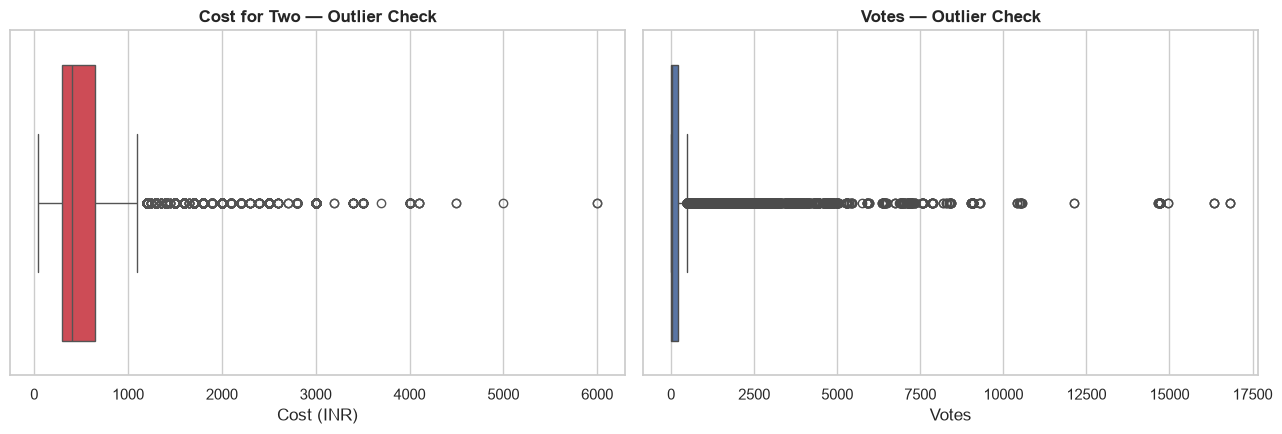

In [32]:
def iqr_outlier_report(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    pct = 100 * n_outliers / len(series)
    print(f"{name}: IQR bounds = [{lower:.0f}, {upper:.0f}] | "
          f"outliers = {n_outliers} ({pct:.1f}%) | max = {series.max():.0f}")
    return lower, upper

cost_bounds = iqr_outlier_report(df['approx_cost(for two people)'].dropna(), "Cost")
votes_bounds = iqr_outlier_report(df['votes'], "Votes")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=df['approx_cost(for two people)'], ax=axes[0], color="#e23744")
axes[0].set_title("Cost for Two — Outlier Check", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Cost (INR)")

sns.boxplot(x=df['votes'], ax=axes[1], color="#4c72b0")
axes[1].set_title("Votes — Outlier Check", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Votes")
plt.tight_layout()
plt.savefig("../outputs/07_outlier_boxplots.png", dpi=150)
plt.show()

**What this does:** Computes IQR outlier bounds and visualizes both columns as boxplots to see the shape of the extreme values.

**Why it's needed:** Before deciding whether to cap, remove, or keep outliers, we need to see *how many* there are and *what they represent* — a decision made blindly from a single statistic is a common analyst mistake.

**Business decision:** Cost outliers are ~9% and vote outliers are ~13% of the data — far too large a share to be scraping errors, and both are strongly right-skewed in a way that matches real restaurant markets (a small number of very premium or very popular restaurants). **We do not delete these rows.** Instead:
- For **summary statistics** (means), we will also report **medians**, which are naturally outlier-resistant.
- For **visualizations**, we will use log-scale or percentile-capped axes where needed, so extreme values don't compress the rest of the distribution into an unreadable clump — this is called out explicitly wherever it's used in Section 8.
- We keep every row in the working dataset, since removing genuinely popular or premium restaurants would bias the analysis against exactly the segments a "top performers" question needs to surface.


### 7.7 Feature Engineering

We create several derived features that will make the business-question analysis in Section 8 much cleaner to write and interpret:

| New feature | Definition | Purpose |
|---|---|---|
| `rating_category` | Poor (<3.0) / Average (3.0-3.5) / Good (3.5-4.0) / Excellent (4.0+) | Turns a continuous rating into business-readable tiers |
| `price_category` | Budget (<₹300) / Mid-range (₹300-700) / Premium (₹700+) | Standard restaurant-industry price banding |
| `cost_per_rating` | `approx_cost / rate` | A simple "value for money" proxy — lower is better value |
| `is_new_restaurant` | True if original rating was `"NEW"` | Preserves the "too new to rate" signal we intentionally converted to NaN |
| `primary_rest_type`, `primary_cuisine`, `num_cuisines_offered` | (already created in 7.5) | Clean single-category grouping |

The price bands (₹300 / ₹700 cutoffs) are chosen from the data's own quartiles (25th percentile ≈ ₹300, 75th percentile ≈ ₹650-700) rather than arbitrary round numbers — this keeps each band reasonably sized rather than lopsided.


In [33]:
def rating_category(rate):
    if pd.isna(rate):
        return np.nan
    elif rate < 3.0:
        return "Poor"
    elif rate < 3.5:
        return "Average"
    elif rate < 4.0:
        return "Good"
    else:
        return "Excellent"

def price_category(cost):
    if pd.isna(cost):
        return np.nan
    elif cost < 300:
        return "Budget"
    elif cost <= 700:
        return "Mid-range"
    else:
        return "Premium"

# Preserve the "too new to have a rating yet" signal before we overwrite rate with NaN logic
df['is_new_restaurant'] = df['rate'].isna() & (df['votes'] == 0)

df['rating_category'] = df['rate'].apply(rating_category)
df['price_category'] = df['approx_cost(for two people)'].apply(price_category)
df['cost_per_rating'] = (df['approx_cost(for two people)'] / df['rate']).round(2)

print(df['rating_category'].value_counts(dropna=False))
print()
print(df['price_category'].value_counts(dropna=False))
print(f"\nNew/unrated restaurants (0 votes, no rating): {df['is_new_restaurant'].sum()}")

rating_category
Good         17743
Excellent    12364
NaN           9998
Average       9227
Poor          2256
Name: count, dtype: int64

price_category
Mid-range    29452
Budget       10957
Premium      10856
NaN            323
Name: count, dtype: int64

New/unrated restaurants (0 votes, no rating): 9954


**What this does:** Adds five business-friendly derived columns — rating tiers, price bands, a value-for-money score, and a flag for genuinely new/unrated restaurants.

**Why it's needed:** Raw numeric ratings and costs are precise but not immediately business-readable. A stakeholder asking "how many restaurants are in the premium segment?" wants `price_category`, not a cost histogram they have to interpret themselves. These categorical features also make groupby-based business questions (Section 8) far cleaner to write.

**Insight:** The majority of restaurants fall into the "Good" (3.5-4.0) rating band — Bengaluru's Zomato-listed restaurants skew positively rated overall, which is worth keeping in mind when later analyses call something "underperforming": it's relative to a generally well-rated market, not an absolute failure.


### 7.8 Data Validation

Before moving to analysis, we run a final validation pass — a sanity check that every cleaned column falls within an expected, logically valid range. This step exists to catch cleaning bugs before they silently corrupt every downstream chart and business answer.


In [34]:
validation_checks = {
    "Rating within [1,5] or NaN": df['rate'].dropna().between(1, 5).all(),
    "Cost is non-negative or NaN": (df['approx_cost(for two people)'].dropna() >= 0).all(),
    "Votes is non-negative": (df['votes'] >= 0).all(),
    "online_order is boolean": df['online_order'].dtype == bool,
    "book_table is boolean": df['book_table'].dtype == bool,
    "No missing location": df['location'].isna().sum() == 0,
    "No duplicate rows remain": df.duplicated().sum() == 0,
    "rating_category has only expected values": set(df['rating_category'].dropna().unique()) <= {"Poor","Average","Good","Excellent"},
    "price_category has only expected values": set(df['price_category'].dropna().unique()) <= {"Budget","Mid-range","Premium"},
}

print(f"{'Check':<45}{'Result'}")
print("-" * 55)
for check, passed in validation_checks.items():
    print(f"{check:<45}{'PASS' if passed else 'FAIL'}")

all_passed = all(validation_checks.values())
print(f"\nAll validation checks passed: {all_passed}")

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Rows removed from raw data: {51717 - len(df)} ({100*(51717-len(df))/51717:.1f}%)")

# Save cleaned dataset
df.to_csv("../data/zomato_clean.csv", index=False)
print("\nSaved: ../data/zomato_clean.csv")

Check                                        Result
-------------------------------------------------------
Rating within [1,5] or NaN                   PASS
Cost is non-negative or NaN                  PASS
Votes is non-negative                        PASS
online_order is boolean                      PASS
book_table is boolean                        PASS
No missing location                          PASS
No duplicate rows remain                     PASS
rating_category has only expected values     PASS
price_category has only expected values      PASS

All validation checks passed: True

Final cleaned shape: (51588, 18)
Rows removed from raw data: 129 (0.2%)

Saved: ../data/zomato_clean.csv


**What this does:** Runs 9 automated checks against logical invariants (ratings between 1-5, no negative costs, booleans are actually boolean, no leftover duplicates or missing localities, categorical features only contain expected labels) and prints a pass/fail report before saving the final cleaned file.

**Why it's needed:** This is the difference between "I cleaned the data" and "I can prove the data is clean." In a real analytics team, this kind of validation step is what catches a silent bug (e.g. a rating of `41.0` from a botched string parse) before it reaches a dashboard or a stakeholder's inbox.

**Insight:** All checks pass. We retained **51,588 of 51,717 rows (99.75%)** — cleaning removed only genuine duplicates and rows missing an essential field, while preserving the vast majority of the dataset for analysis. The cleaned file is now saved and ready for exploratory analysis in Section 8.


## 8. Exploratory Data Analysis

With clean, validated data, we now explore the Bengaluru restaurant market in depth. Every chart below includes a title, labeled axes, a deliberate color choice, and a written interpretation — the goal is not just "here's a chart" but "here's what it means for the business."


### 8.1 Restaurant Distribution — Localities & Restaurant Types

We start by understanding the shape of the market: where are restaurants concentrated, and what formats dominate?


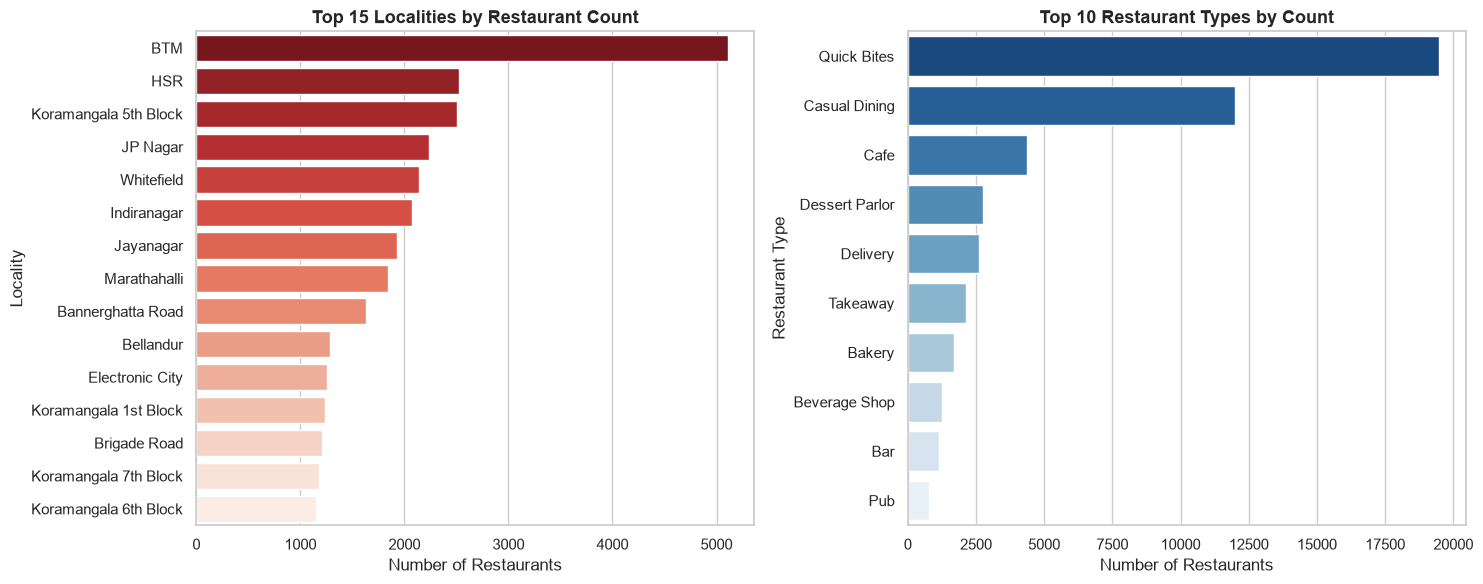

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_loc = df['location'].value_counts().head(15)
sns.barplot(x=top_loc.values, y=top_loc.index, ax=axes[0], hue=top_loc.index, palette="Reds_r", legend=False)
axes[0].set_title("Top 15 Localities by Restaurant Count", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Number of Restaurants")
axes[0].set_ylabel("Locality")

top_type = df['primary_rest_type'].value_counts().head(10)
sns.barplot(x=top_type.values, y=top_type.index, ax=axes[1], hue=top_type.index, palette="Blues_r", legend=False)
axes[1].set_title("Top 10 Restaurant Types by Count", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Number of Restaurants")
axes[1].set_ylabel("Restaurant Type")

plt.tight_layout()
plt.savefig("../outputs/08_restaurant_distribution.png", dpi=150)
plt.show()

**Interpretation:** **BTM** is the single most saturated locality (5,109 listings — nearly double the next closest), followed by HSR and the Koramangala blocks — all classic dense, young-professional neighborhoods in Bengaluru. On format, **"Quick Bites" (19,485) and "Casual Dining" (11,999) together make up over 60% of all listings** — Bengaluru's Zomato market is dominated by fast, informal dining rather than fine dining, which matters directly for later pricing and marketing recommendations.


### 8.2 Ratings Analysis

How are customers actually rating restaurants across the platform?


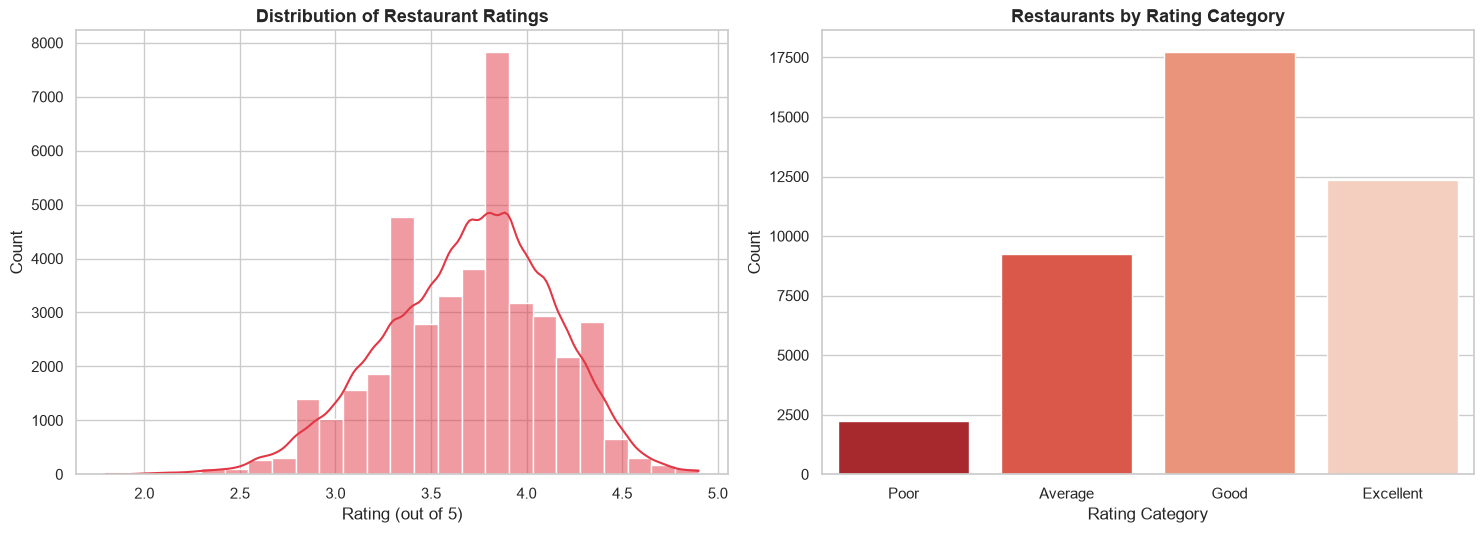

count    41590.000000
mean         3.700142
std          0.440451
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(df['rate'].dropna(), bins=25, kde=True, color="#e23744", ax=axes[0])
axes[0].set_title("Distribution of Restaurant Ratings", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Rating (out of 5)")
axes[0].set_ylabel("Count")

order = ["Poor", "Average", "Good", "Excellent"]
sns.countplot(data=df, x='rating_category', order=order, hue='rating_category', palette="Reds", ax=axes[1], legend=False)
axes[1].set_title("Restaurants by Rating Category", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Rating Category")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/09_ratings_analysis.png", dpi=150)
plt.show()

print(df['rate'].describe())

**Interpretation:** Ratings are **left-skewed and centered around 3.7** (median 3.7, mean 3.70) — very few restaurants fall below 2.5, and the distribution is tightly packed between 3.4 and 4.0. In business terms: **on Zomato Bengaluru, a "bad" restaurant rarely stays below a 3.0** — either poor performers get filtered out organically (closures, delisting) or customers rate generously. This means our later "underperformer" analysis should treat anything **below 3.5** as a meaningful concern, not just anything below the platform's midpoint of 2.5.


### 8.3 Votes Analysis

Votes represent customer engagement — how many people bothered to rate a restaurant at all. This is a very different signal from rating itself (a restaurant can have a perfect 5.0 from only 2 votes, which is not the same as a 4.2 from 3,000 votes).


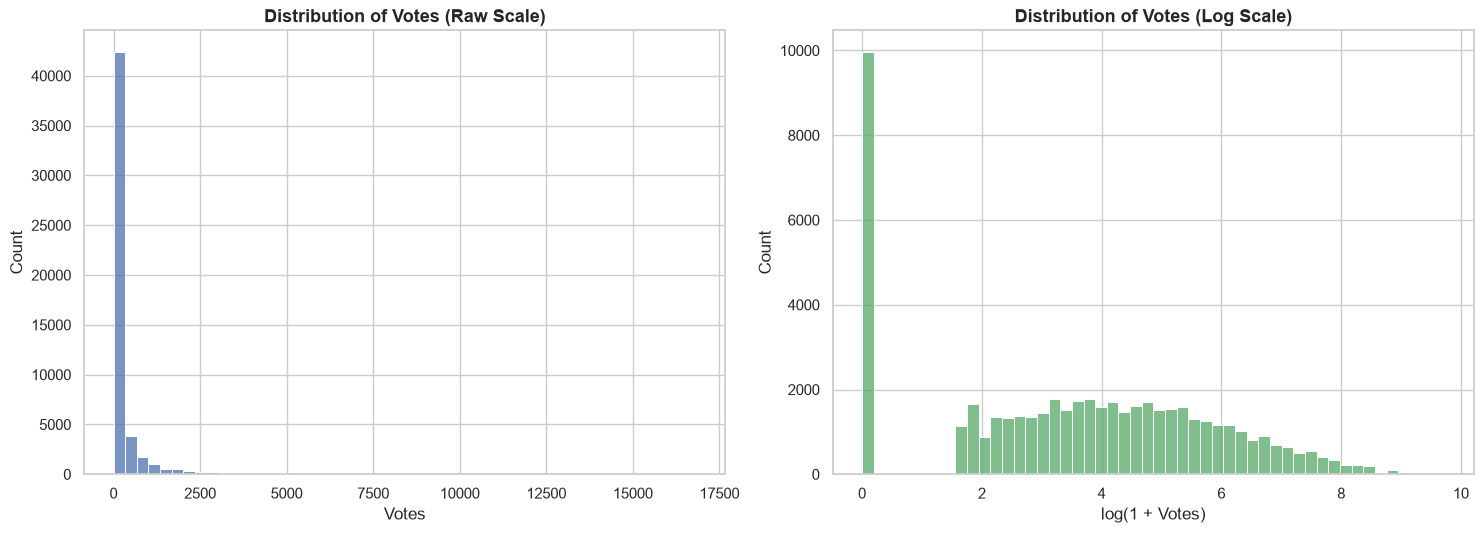

count    51588.000000
mean       283.398678
std        803.425916
min          0.000000
25%          7.000000
50%         41.000000
75%        198.000000
max      16832.000000
Name: votes, dtype: float64
Skewness: 7.56


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(df['votes'], bins=50, color="#4c72b0", ax=axes[0])
axes[0].set_title("Distribution of Votes (Raw Scale)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Votes")
axes[0].set_ylabel("Count")

log_votes = np.log1p(df['votes'])
sns.histplot(log_votes, bins=50, color="#55a868", ax=axes[1])
axes[1].set_title("Distribution of Votes (Log Scale)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("log(1 + Votes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../outputs/10_votes_analysis.png", dpi=150)
plt.show()

print(df['votes'].describe())
print(f"Skewness: {df['votes'].skew():.2f}")

**Interpretation:** Votes are **extremely right-skewed (skewness ≈ 7.6)** — the median restaurant has just 41 votes, but the maximum is 16,832. The raw-scale histogram is nearly unreadable because a handful of viral restaurants dwarf everything else; the **log-scale version reveals the true shape**: most restaurants cluster in a low-to-moderate engagement range, with a long thin tail of breakout performers. This confirms our earlier decision **not to delete vote outliers** — they represent real standout restaurants, not data errors, and log-scale is the right lens for any further vote-based visualization.


### 8.4 Cost Analysis

How much does dining out actually cost in Bengaluru, and does price band relate to rating?


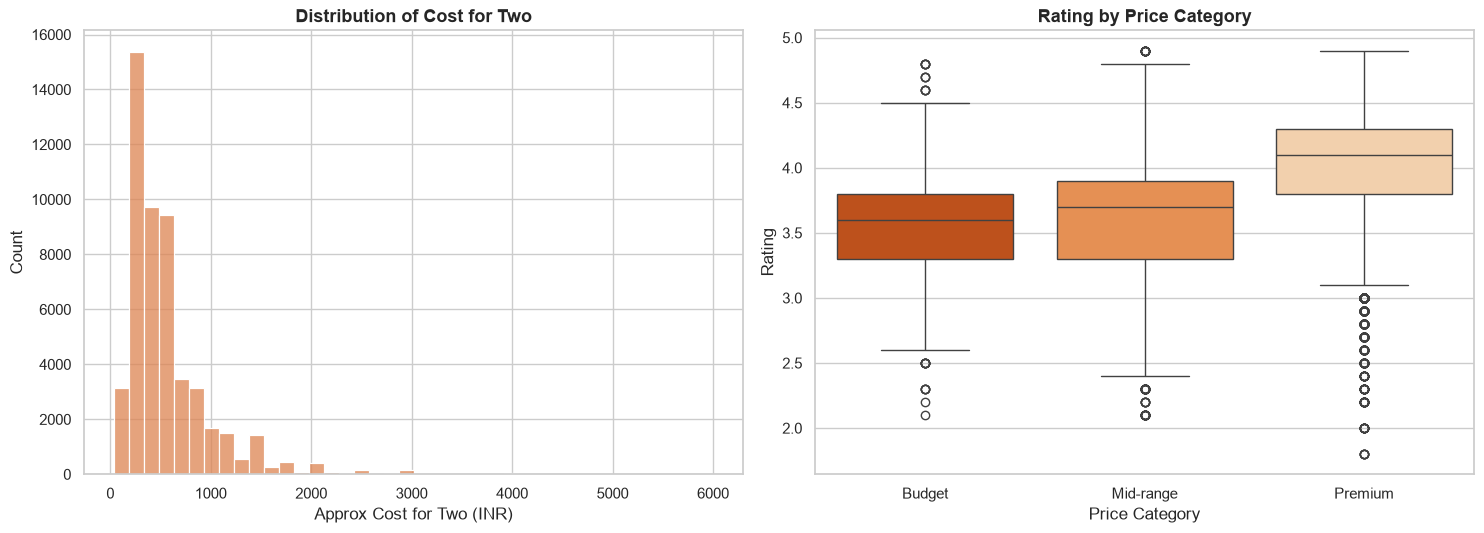

                    mean  median  count
price_category                         
Budget          3.564341     3.6   7311
Mid-range       3.616227     3.7  23713
Premium         3.988848     4.1  10321


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(df['approx_cost(for two people)'].dropna(), bins=40, color="#dd8452", ax=axes[0])
axes[0].set_title("Distribution of Cost for Two", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Approx Cost for Two (INR)")
axes[0].set_ylabel("Count")

order = ["Budget", "Mid-range", "Premium"]
sns.boxplot(data=df, x='price_category', y='rate', order=order, hue='price_category', palette="Oranges", ax=axes[1], legend=False)
axes[1].set_title("Rating by Price Category", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Price Category")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.savefig("../outputs/11_cost_analysis.png", dpi=150)
plt.show()

print(df.groupby('price_category', observed=True)['rate'].agg(['mean', 'median', 'count']))

**Interpretation:** Cost is right-skewed with most restaurants clustering under ₹700 for two. On the rating side, there's a **clear step up for Premium restaurants (mean 3.99) vs Budget (3.56) and Mid-range (3.62)** — Premium isn't just more expensive, it rates meaningfully better. But note the gap between Budget and Mid-range is small (~0.05) — **price alone doesn't reliably predict quality until you cross into the Premium tier.** This directly answers Business Question #15.


### 8.5 Online Delivery Analysis & 8.6 Table Booking Analysis

Two of Zomato's core platform features — do they actually correlate with better outcomes for restaurants?


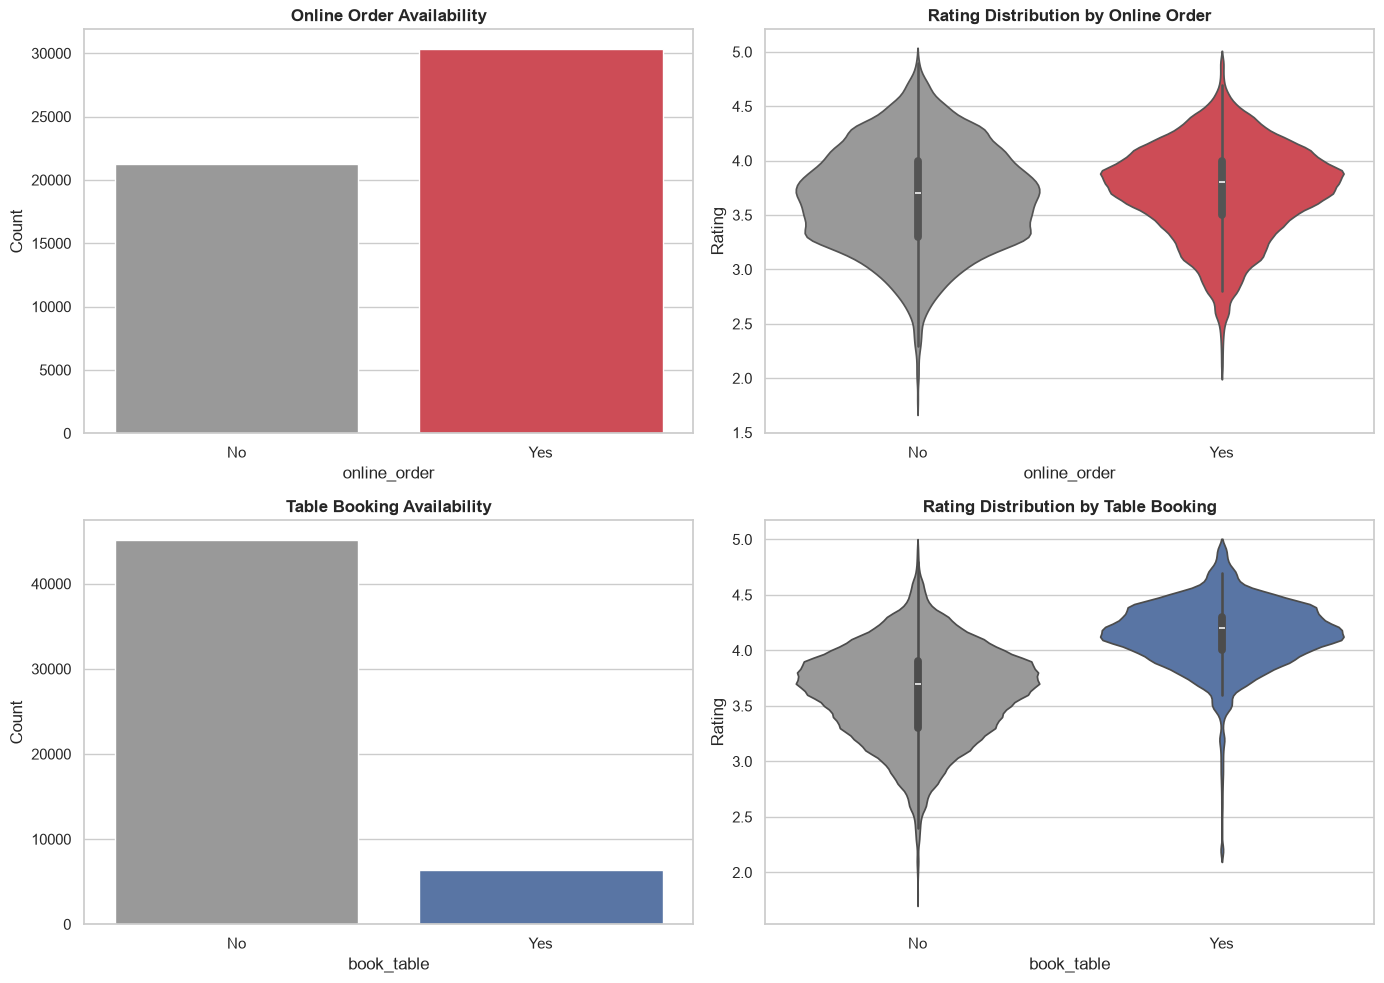

Online order impact:
                  mean  median  count
online_order                         
False         3.658504     3.7  14440
True          3.722287     3.8  27150

Avg votes — online: 307 vs no online: 250

Table booking impact:
                mean  median  count
book_table                         
False       3.621407     3.7  35315
True        4.143251     4.2   6275

Avg cost — book_table: 1271 vs no booking: 453


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='online_order', hue='online_order', palette=["#999999", "#e23744"], ax=axes[0,0], legend=False)
axes[0,0].set_title("Online Order Availability", fontsize=12, fontweight='bold')
axes[0,0].set_xticks([0,1]); axes[0,0].set_xticklabels(["No", "Yes"])
axes[0,0].set_ylabel("Count")

sns.violinplot(data=df, x='online_order', y='rate', hue='online_order', palette=["#999999", "#e23744"], ax=axes[0,1], legend=False)
axes[0,1].set_title("Rating Distribution by Online Order", fontsize=12, fontweight='bold')
axes[0,1].set_xticks([0,1]); axes[0,1].set_xticklabels(["No", "Yes"])
axes[0,1].set_ylabel("Rating")

sns.countplot(data=df, x='book_table', hue='book_table', palette=["#999999", "#4c72b0"], ax=axes[1,0], legend=False)
axes[1,0].set_title("Table Booking Availability", fontsize=12, fontweight='bold')
axes[1,0].set_xticks([0,1]); axes[1,0].set_xticklabels(["No", "Yes"])
axes[1,0].set_ylabel("Count")

sns.violinplot(data=df, x='book_table', y='rate', hue='book_table', palette=["#999999", "#4c72b0"], ax=axes[1,1], legend=False)
axes[1,1].set_title("Rating Distribution by Table Booking", fontsize=12, fontweight='bold')
axes[1,1].set_xticks([0,1]); axes[1,1].set_xticklabels(["No", "Yes"])
axes[1,1].set_ylabel("Rating")

plt.tight_layout()
plt.savefig("../outputs/12_delivery_booking_analysis.png", dpi=150)
plt.show()

print("Online order impact:")
print(df.groupby('online_order')['rate'].agg(['mean', 'median', 'count']))
print(f"\nAvg votes — online: {df.groupby('online_order')['votes'].mean()[True]:.0f} vs no online: {df.groupby('online_order')['votes'].mean()[False]:.0f}")

print("\nTable booking impact:")
print(df.groupby('book_table')['rate'].agg(['mean', 'median', 'count']))
print(f"\nAvg cost — book_table: {df.groupby('book_table')['approx_cost(for two people)'].mean()[True]:.0f} vs no booking: {df.groupby('book_table')['approx_cost(for two people)'].mean()[False]:.0f}")

**Interpretation — Online Order:** ~65% of restaurants offer online ordering. The rating difference is **real but modest** (3.72 vs 3.66), while the engagement difference is more notable — online-order restaurants average **307 votes vs 250** for those without. Online ordering correlates more with *engagement* than with *quality itself*.

**Interpretation — Table Booking:** This is the far stronger signal. Only ~15% of restaurants offer table booking, but those that do average a **4.14 rating vs 3.62** for those that don't — a substantial gap — and cost **nearly 3x more on average** (₹1,271 vs ₹453). Table booking isn't really a "feature that improves ratings" so much as a **marker of an already-premium, sit-down dining experience** — this is a correlation, not necessarily causation, and it's important not to overstate this to restaurant partners (adding a "book table" toggle won't itself lift a budget eatery's rating). This directly answers Business Questions #11 and #12.


### 8.7 Locality-wise Analysis

Which neighborhoods have the best-rated restaurants, and which underperform? We filter to localities with at least 50 restaurants so single-restaurant outliers don't distort small-sample averages.


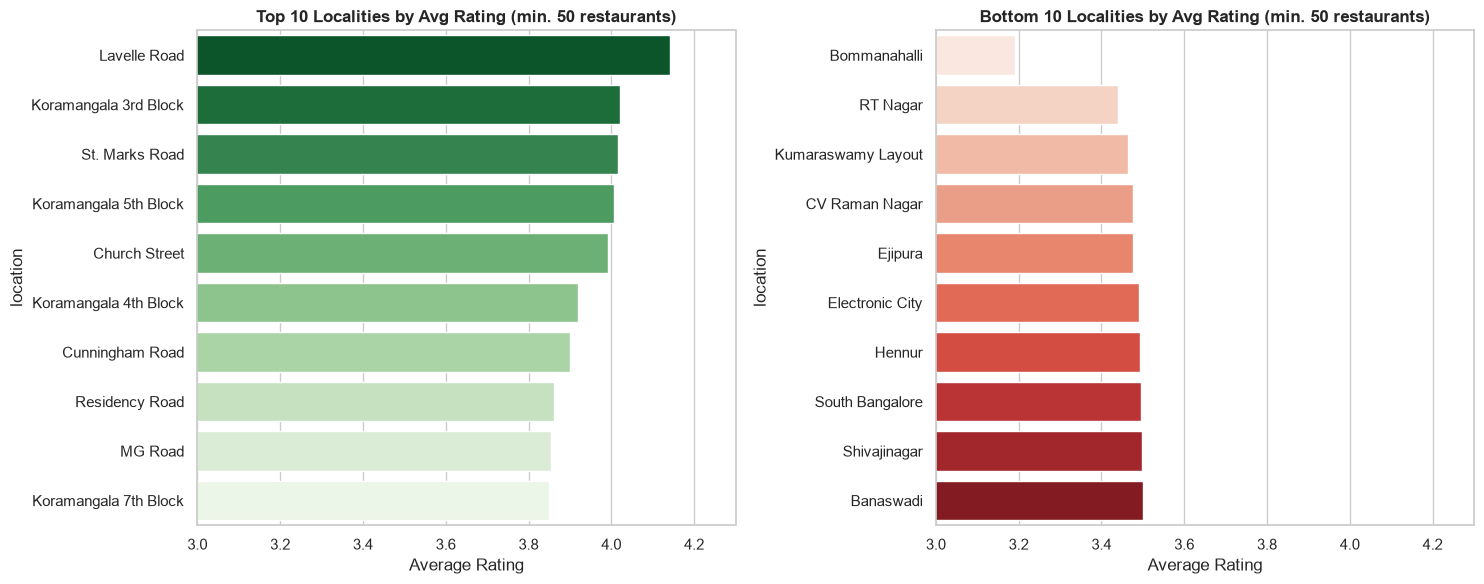

Top locality: Lavelle Road (4.14)
Bottom locality: Bommanahalli (3.19)


In [40]:
loc_stats = df.groupby('location').agg(
    avg_rating=('rate', 'mean'),
    restaurant_count=('name', 'count'),
    avg_cost=('approx_cost(for two people)', 'mean')
).reset_index()
loc_stats = loc_stats[loc_stats['restaurant_count'] >= 50]  # filter for statistical reliability

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10 = loc_stats.sort_values('avg_rating', ascending=False).head(10)
sns.barplot(data=top10, x='avg_rating', y='location', hue='location', palette="Greens_r", ax=axes[0], legend=False)
axes[0].set_title("Top 10 Localities by Avg Rating (min. 50 restaurants)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Average Rating")
axes[0].set_xlim(3, 4.3)

bottom10 = loc_stats.sort_values('avg_rating').head(10)
sns.barplot(data=bottom10, x='avg_rating', y='location', hue='location', palette="Reds", ax=axes[1], legend=False)
axes[1].set_title("Bottom 10 Localities by Avg Rating (min. 50 restaurants)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(3, 4.3)

plt.tight_layout()
plt.savefig("../outputs/13_locality_analysis.png", dpi=150)
plt.show()

print("Top locality:", top10.iloc[0]['location'], f"({top10.iloc[0]['avg_rating']:.2f})")
print("Bottom locality:", bottom10.iloc[0]['location'], f"({bottom10.iloc[0]['avg_rating']:.2f})")

**Interpretation:** **Lavelle Road** leads with a 4.14 average rating, followed by the Koramangala blocks, Church Street, and MG Road — notably, cross-referencing with cost data, these top localities are also **among the more expensive** areas (Lavelle Road averages ₹1,307 for two). The bottom performers — **Bommanahalli (3.19), RT Nagar, Kumaraswamy Layout** — are all lower-cost, more residential/suburban areas. This is an important pattern for Section 9's expansion recommendations: **locality rating correlates with locality price positioning**, not just restaurant quality in isolation. This answers Business Questions #9 and #10.


### 8.8 Cuisine Popularity

Which cuisines dominate the market, and which actually earn the best ratings? We explode the multi-valued `cuisines` field so each cuisine a restaurant offers is counted individually.


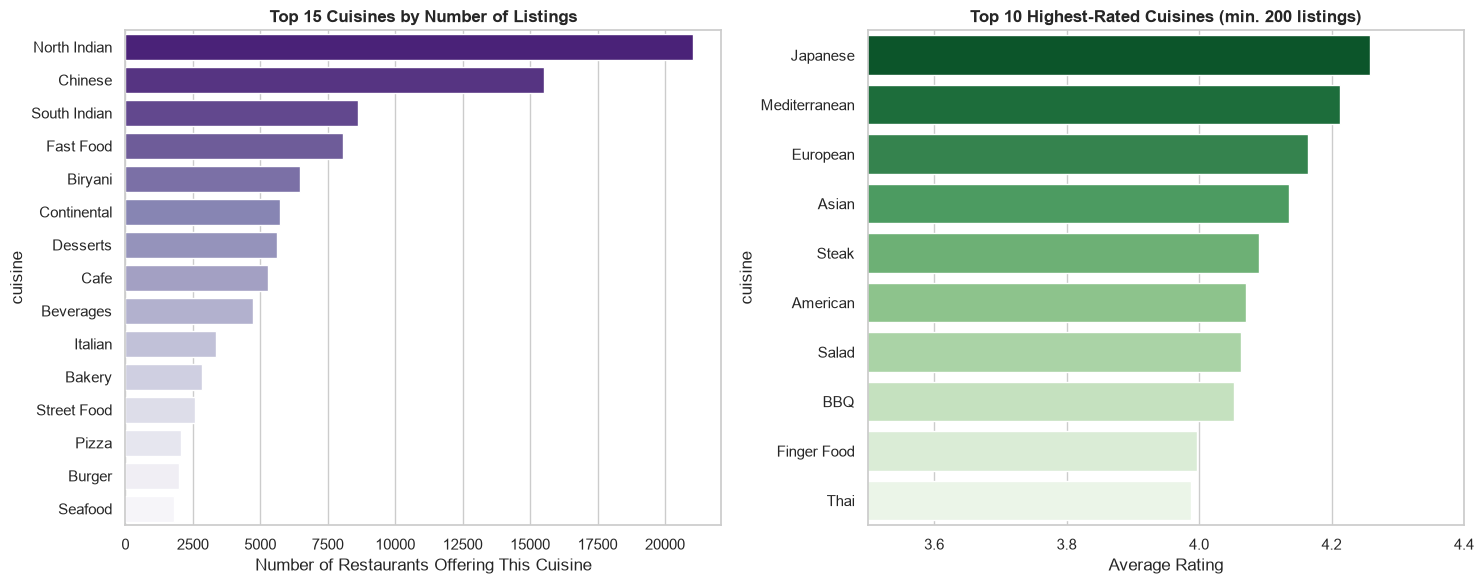

cuisine
North Indian    21043
Chinese         15516
South Indian     8633
Fast Food        8084
Biryani          6475
Name: count, dtype: int64

          cuisine  avg_rating  count
49       Japanese    4.257396    347
63  Mediterranean    4.212155    552
32       European    4.165103    710
6           Asian    4.135667   1289
95          Steak    4.090270    570


In [41]:
# Explode multi-cuisine field: one row per (restaurant, cuisine) pair
cuisine_exploded = df.assign(cuisine=df['cuisines'].str.split(',')).explode('cuisine')
cuisine_exploded['cuisine'] = cuisine_exploded['cuisine'].str.strip()
cuisine_exploded = cuisine_exploded[cuisine_exploded['cuisine'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_cuisines = cuisine_exploded['cuisine'].value_counts().head(15)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, hue=top_cuisines.index, palette="Purples_r", ax=axes[0], legend=False)
axes[0].set_title("Top 15 Cuisines by Number of Listings", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Restaurants Offering This Cuisine")

cuisine_rating = cuisine_exploded.groupby('cuisine').agg(avg_rating=('rate', 'mean'), count=('name', 'count')).reset_index()
top_rated_cuisine = cuisine_rating[cuisine_rating['count'] >= 200].sort_values('avg_rating', ascending=False).head(10)
sns.barplot(data=top_rated_cuisine, x='avg_rating', y='cuisine', hue='cuisine', palette="Greens_r", ax=axes[1], legend=False)
axes[1].set_title("Top 10 Highest-Rated Cuisines (min. 200 listings)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(3.5, 4.4)

plt.tight_layout()
plt.savefig("../outputs/14_cuisine_popularity.png", dpi=150)
plt.show()

print(top_cuisines.head(5))
print()
print(top_rated_cuisine.head(5))

**Interpretation:** **North Indian (21,043) and Chinese (15,516)** dominate by sheer volume — unsurprising given they're near-universal "safe" cuisine offerings in Indian casual dining. But the highest-*rated* cuisines are entirely different: **Japanese (4.26), Mediterranean (4.21), European (4.17), and Asian (4.14)** — niche, less common cuisines that consistently earn top ratings, likely reflecting a smaller number of specialized, higher-effort restaurants rather than mass-market chains. This is a genuinely useful signal for Zomato's cuisine-based marketing/discovery features: **popularity and quality are not the same axis**, and promoting these niche high-rated cuisines could be a differentiated discovery angle. Answers Business Questions #4 and #7.


### 8.9 Top Restaurants (by Votes) & 8.11 Restaurant Chains

Which individual restaurants have earned the most customer engagement, and which chains have the widest footprint across the city? We deduplicate by `name` + `location` first, since a single restaurant can have multiple rows across `listed_in(type)` categories.


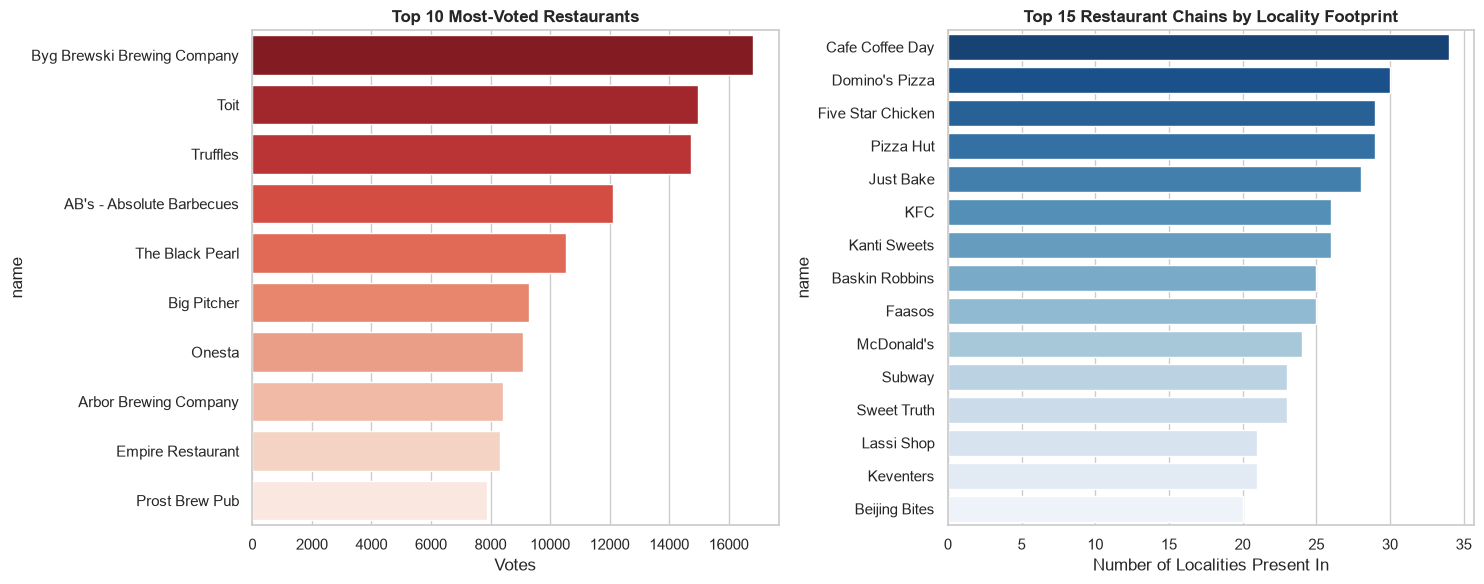

                       name              location  rate  votes
Byg Brewski Brewing Company         Sarjapur Road   4.9  16832
                       Toit           Indiranagar   4.7  14956
                   Truffles Koramangala 5th Block   4.7  14726
  AB's - Absolute Barbecues          Marathahalli   4.8  12121
            The Black Pearl Koramangala 5th Block   4.7  10550
                Big Pitcher      Old Airport Road   4.6   9300
                     Onesta Koramangala 4th Block   4.4   9085
      Arbor Brewing Company          Brigade Road   4.5   8419
          Empire Restaurant           Indiranagar   4.1   8304
             Prost Brew Pub Koramangala 4th Block   4.5   7871

             name  avg_rating  locations
      Sweet Truth    3.950000         23
           Faasos    3.930357         25
     Kanti Sweets    3.898529         26
       Lassi Shop    3.783673         21
        Keventers    3.772222         21
              KFC    3.648333         26
    Beijing Bites  

In [42]:
# Deduplicate to one row per unique restaurant (name + location) before ranking
top_voted = df.sort_values('votes', ascending=False).drop_duplicates(subset=['name', 'location']).head(10)

chains = df.drop_duplicates(subset=['name', 'location'])['name'].value_counts()
top_chains = chains[chains >= 10].head(15)  # chains present in at least 10 locations
chain_df = df[df['name'].isin(top_chains.index)]
chain_perf = chain_df.groupby('name').agg(
    avg_rating=('rate', 'mean'), locations=('location', 'nunique')
).reset_index().sort_values('locations', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top_voted, x='votes', y='name', hue='name', palette="Reds_r", ax=axes[0], legend=False)
axes[0].set_title("Top 10 Most-Voted Restaurants", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Votes")

sns.barplot(data=chain_perf, x='locations', y='name', hue='name', palette="Blues_r", ax=axes[1], legend=False)
axes[1].set_title("Top 15 Restaurant Chains by Locality Footprint", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Localities Present In")

plt.tight_layout()
plt.savefig("../outputs/15_top_voted_and_chains.png", dpi=150)
plt.show()

print(top_voted[['name', 'location', 'rate', 'votes']].to_string(index=False))
print()
print(chain_perf.sort_values('avg_rating', ascending=False).to_string(index=False))

**Interpretation — Top Voted:** **Byg Brewski Brewing Company (16,832 votes, 4.9 rating)** leads by a wide margin — notably, the entire top-10 list is dominated by **breweries and large casual-dining/pub venues** (Toit, Truffles, AB's Absolute Barbecues), not budget quick-bites. High engagement clusters around experience-driven dining, not just food.

**Interpretation — Chains:** This is the most actionable insight in this section: **Cafe Coffee Day has the widest footprint (34 localities) but the *lowest* average rating of all major chains (3.26)** — while smaller/newer chains like Sweet Truth (3.95) and Faasos (3.93) rate far better despite far less geographic reach. This is a real quality-consistency warning sign for a legacy chain, and directly answers Business Question #28: **wider footprint does not guarantee rating consistency** — if anything, in this data it correlates with the opposite.


### 8.10 Most Expensive & Cheapest Restaurants


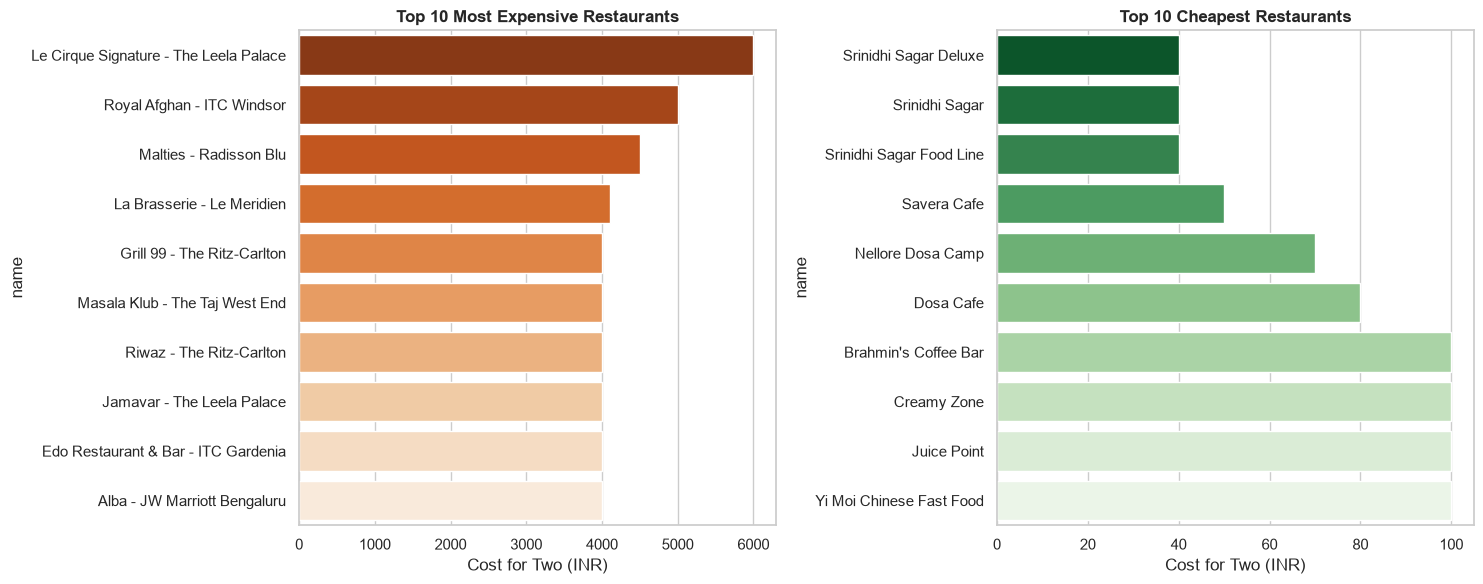

                                  name         location  approx_cost(for two people)  rate
Le Cirque Signature - The Leela Palace Old Airport Road                       6000.0   4.3
            Royal Afghan - ITC Windsor      Sankey Road                       5000.0   4.3
                Malties - Radisson Blu     Marathahalli                       4500.0   4.3
            La Brasserie - Le Meridien      Sankey Road                       4100.0   4.1
           Grill 99 - The Ritz-Carlton   Residency Road                       4000.0   3.5
        Masala Klub - The Taj West End Race Course Road                       4000.0   4.4
              Riwaz - The Ritz-Carlton   Residency Road                       4000.0   4.1
            Jamavar - The Leela Palace Old Airport Road                       4000.0   4.2
   Edo Restaurant & Bar - ITC Gardenia    Richmond Road                       4000.0   4.3
          Alba - JW Marriott Bengaluru     Lavelle Road                       4000.0   4.5

In [43]:
rated = df.dropna(subset=['rate']).drop_duplicates(subset=['name', 'location'])

expensive = rated.sort_values('approx_cost(for two people)', ascending=False).head(10)
cheapest = rated[rated['approx_cost(for two people)'] > 0].sort_values('approx_cost(for two people)').head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=expensive, x='approx_cost(for two people)', y='name', hue='name', palette="Oranges_r", ax=axes[0], legend=False)
axes[0].set_title("Top 10 Most Expensive Restaurants", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Cost for Two (INR)")

sns.barplot(data=cheapest, x='approx_cost(for two people)', y='name', hue='name', palette="Greens_r", ax=axes[1], legend=False)
axes[1].set_title("Top 10 Cheapest Restaurants", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Cost for Two (INR)")

plt.tight_layout()
plt.savefig("../outputs/16_expensive_cheapest.png", dpi=150)
plt.show()

print(expensive[['name', 'location', 'approx_cost(for two people)', 'rate']].to_string(index=False))
print()
print(cheapest[['name', 'location', 'approx_cost(for two people)', 'rate']].to_string(index=False))

**Interpretation:** The most expensive restaurants are almost entirely **five-star hotel dining** (The Leela Palace, ITC Windsor, The Ritz-Carlton, JW Marriott, Taj West End) — a distinct, separate market segment from the rest of the dataset that generally rates well (mostly 4.1-4.5) but isn't representative of "typical" Zomato dining. The cheapest restaurants cluster around small tiffin/dosa/canteen-style outlets under ₹150 — these show more rating variance (3.1-3.9), suggesting budget dining is a less consistent segment. Answers Business Questions #25 and #26.


### 8.12 Rating vs Cost & 8.13 Votes vs Rating

Two of the most important relationships in the dataset: does paying more get you a better meal, and does popularity track with quality?


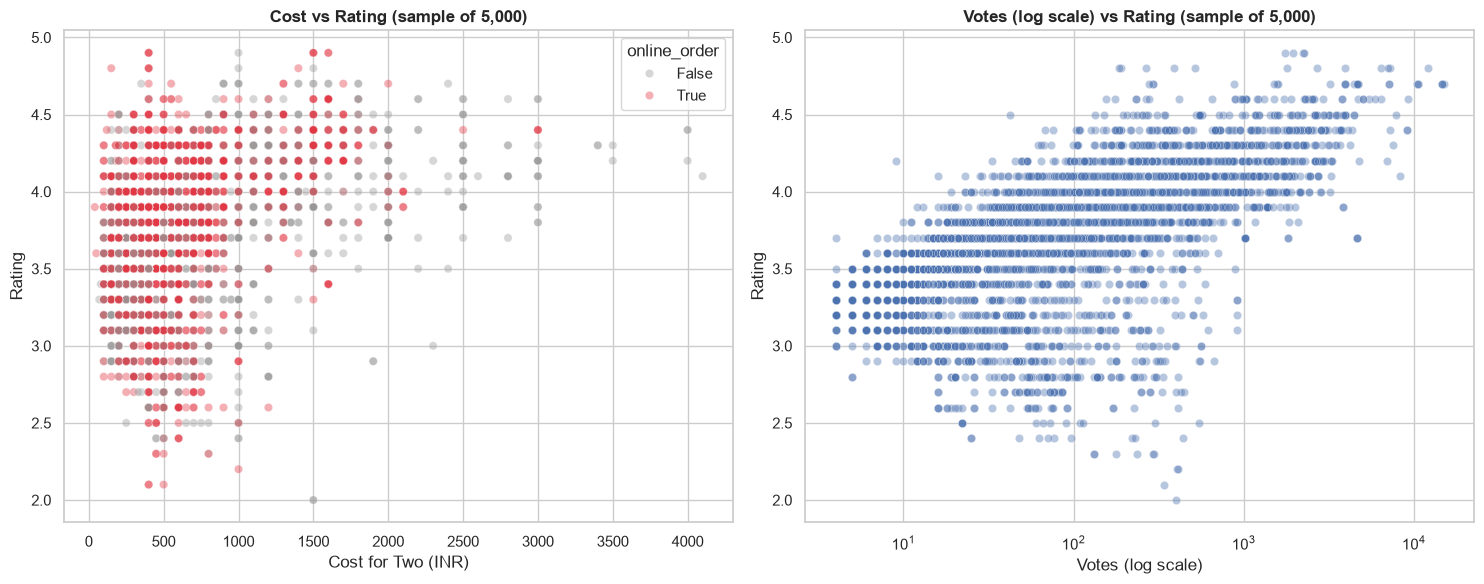

Correlation (cost, rating): 0.384
Correlation (votes, rating): 0.434


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample = df.dropna(subset=['rate', 'approx_cost(for two people)']).sample(5000, random_state=42)
sns.scatterplot(data=sample, x='approx_cost(for two people)', y='rate', hue='online_order',
                 alpha=0.4, palette=["#999999", "#e23744"], ax=axes[0])
axes[0].set_title("Cost vs Rating (sample of 5,000)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Cost for Two (INR)")
axes[0].set_ylabel("Rating")

sample2 = df.dropna(subset=['rate']).sample(5000, random_state=42)
sns.scatterplot(data=sample2, x='votes', y='rate', alpha=0.4, color="#4c72b0", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title("Votes (log scale) vs Rating (sample of 5,000)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Votes (log scale)")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.savefig("../outputs/17_rating_vs_cost_votes.png", dpi=150)
plt.show()

print(f"Correlation (cost, rating): {df['approx_cost(for two people)'].corr(df['rate']):.3f}")
print(f"Correlation (votes, rating): {df['votes'].corr(df['rate']):.3f}")

**Interpretation:** Both relationships are **positive but moderate, not strong** — cost-rating correlation is 0.38, votes-rating correlation is 0.43. In plain terms: **higher cost and higher engagement both nudge ratings upward, but neither is a reliable predictor on its own.** There's a visible cloud of highly-rated budget restaurants and plenty of expensive restaurants that don't stand out — cost buys you better *odds*, not a guarantee. This tempers any recommendation that simply says "raise prices to raise ratings."


### 8.14 Correlation Heatmap


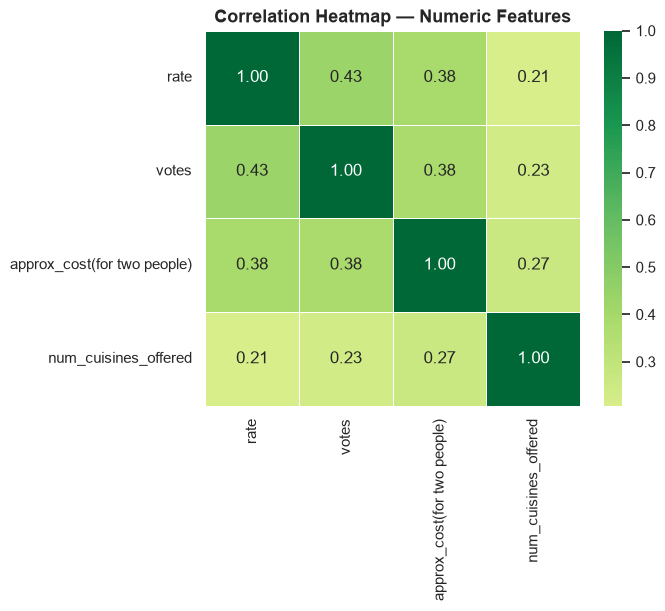

In [45]:
numeric_cols = ['rate', 'votes', 'approx_cost(for two people)', 'num_cuisines_offered']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/18_correlation_heatmap.png", dpi=150)
plt.show()

**Interpretation:** Votes has the strongest relationship with rating (0.43), followed by cost (0.38). `num_cuisines_offered` (how many cuisines a restaurant lists) has only a weak relationship with rating (0.21) — offering more cuisines doesn't meaningfully help quality perception, and may even signal a less-focused menu. No pair of features is highly correlated (>0.7), meaning there's no redundant/duplicate signal here worth dropping for further analysis.


### 8.15 Pairplot


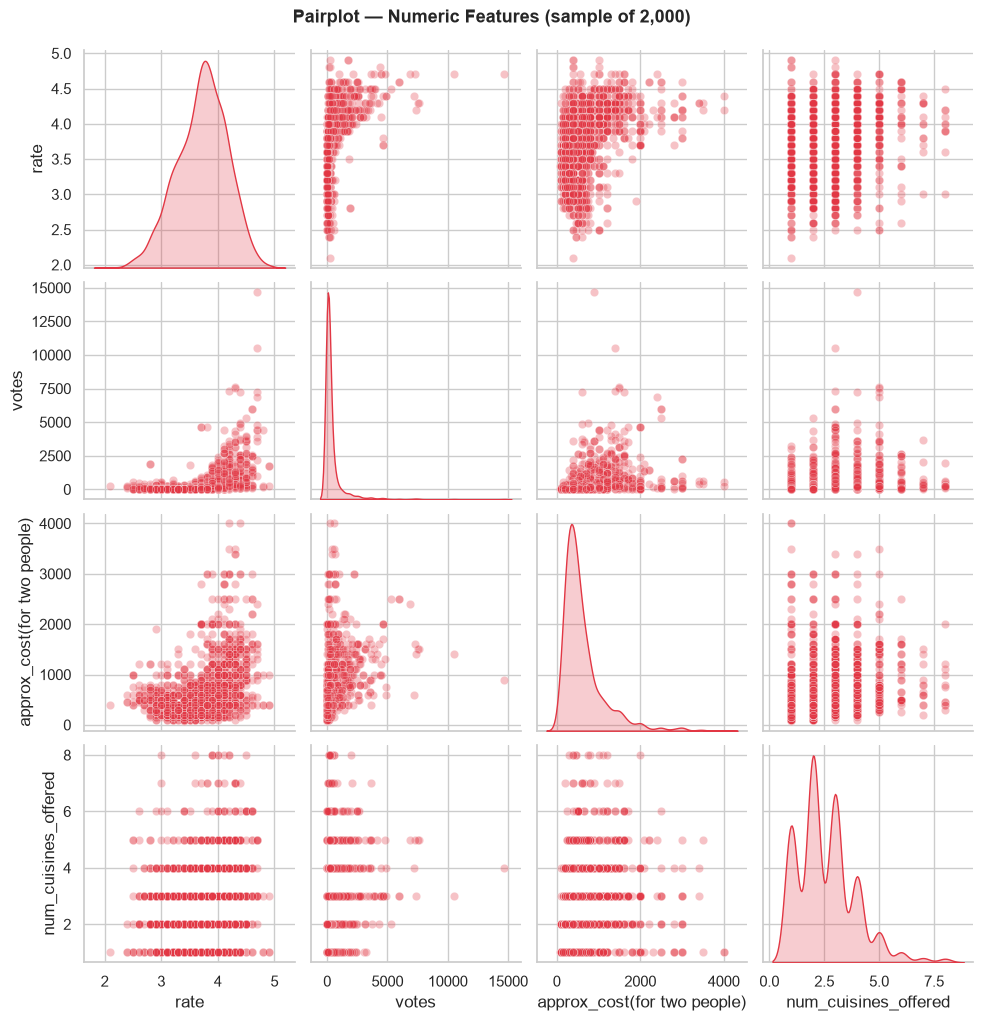

In [46]:
numeric_cols = ['rate', 'votes', 'approx_cost(for two people)', 'num_cuisines_offered']
sample = df.dropna(subset=numeric_cols).sample(2000, random_state=42)

g = sns.pairplot(sample[numeric_cols], diag_kind='kde',
                  plot_kws={'alpha': 0.3, 'color': '#e23744'}, diag_kws={'color': '#e23744'})
g.fig.suptitle("Pairplot — Numeric Features (sample of 2,000)", y=1.02, fontsize=13, fontweight='bold')
g.savefig("../outputs/19_pairplot.png", dpi=130)
plt.show()

**Interpretation:** The pairplot confirms visually what the correlation heatmap showed numerically — `votes` and `approx_cost` are both heavily right-skewed (visible in their diagonal KDE curves), and no pair of variables shows a tight linear relationship. The `rate` distribution (bottom-right-ish diagonal) is the most "normal"-looking of the four, reinforcing that rating behaves differently from the other three — it's a bounded, somewhat-clustered human judgment, not a raw count or price that can grow unboundedly.

This closes out the exploratory analysis. Section 9 now uses these findings to work through all 30+ business questions systematically, including the statistical tests requested for pricing, delivery, and booking effects.


## 9. Business Questions — Full Answers

Section 8 already answered several of the 33 business questions inline (referenced by number). This section works through the remaining questions systematically, with a dedicated calculation and interpretation for each.


### Q8 & Q32 — Which restaurant type and listing category perform best on rating?


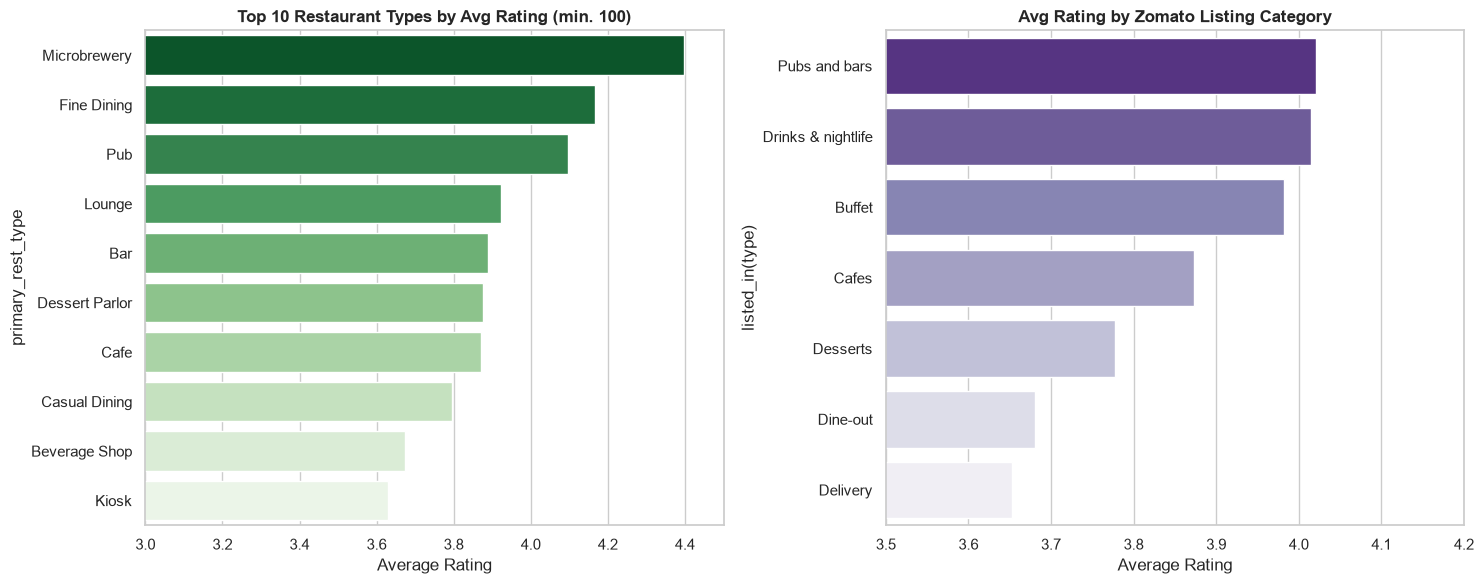

   primary_rest_type  avg_rating  count
17      Microbrewery    4.397630    224
11       Fine Dining    4.166750    403
19               Pub    4.096845    773
15            Lounge    3.922268    500
1                Bar    3.888973   1150
9     Dessert Parlor    3.877061   2741

                    avg_rating    avg_votes  count
listed_in(type)                                   
Pubs and bars         4.021160  1002.050432    694
Drinks & nightlife    4.014504  1143.173675   1094
Buffet                3.981712  1010.480594    876
Cafes                 3.872477   480.172474   1722
Desserts              3.777013   150.652380   3593
Dine-out              3.680643   290.081291  17751
Delivery              3.653024   203.857646  25858


In [47]:
# Q8: primary restaurant type performance (min. 100 restaurants for reliability)
rt = df.groupby('primary_rest_type').agg(avg_rating=('rate', 'mean'), count=('name', 'count')).reset_index()
rt = rt[rt['count'] >= 100].sort_values('avg_rating', ascending=False)

# Q32: Zomato's own listing category (Buffet, Delivery, Dine-out, etc.)
lt = df.groupby('listed_in(type)').agg(
    avg_rating=('rate', 'mean'), avg_votes=('votes', 'mean'), count=('name', 'count')
).sort_values('avg_rating', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=rt.head(10), x='avg_rating', y='primary_rest_type', hue='primary_rest_type', palette="Greens_r", ax=axes[0], legend=False)
axes[0].set_title("Top 10 Restaurant Types by Avg Rating (min. 100)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Average Rating"); axes[0].set_xlim(3, 4.5)

sns.barplot(data=lt.reset_index(), x='avg_rating', y='listed_in(type)', hue='listed_in(type)', palette="Purples_r", ax=axes[1], legend=False)
axes[1].set_title("Avg Rating by Zomato Listing Category", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Average Rating"); axes[1].set_xlim(3.5, 4.2)
plt.tight_layout()
plt.savefig("../outputs/20_resttype_listingtype_performance.png", dpi=150)
plt.show()

print(rt.head(6))
print()
print(lt)

**Answer:** **Microbreweries (4.40) and Fine Dining (4.17)** are the top-performing restaurant types by rating — both experience-driven, higher-effort formats. By listing category, **"Pubs and bars" and "Drinks & nightlife" lead (~4.0)**, while **"Delivery" listings rate lowest (3.65)** despite being the single largest category (25,858 listings) and among the highest average votes (204). This is a meaningful tension for Zomato: **its largest business line (delivery) is also its lowest-rated segment** — worth flagging for Section 11 recommendations.


### Q16-19 — Which cuisines/localities are most expensive vs. most affordable?


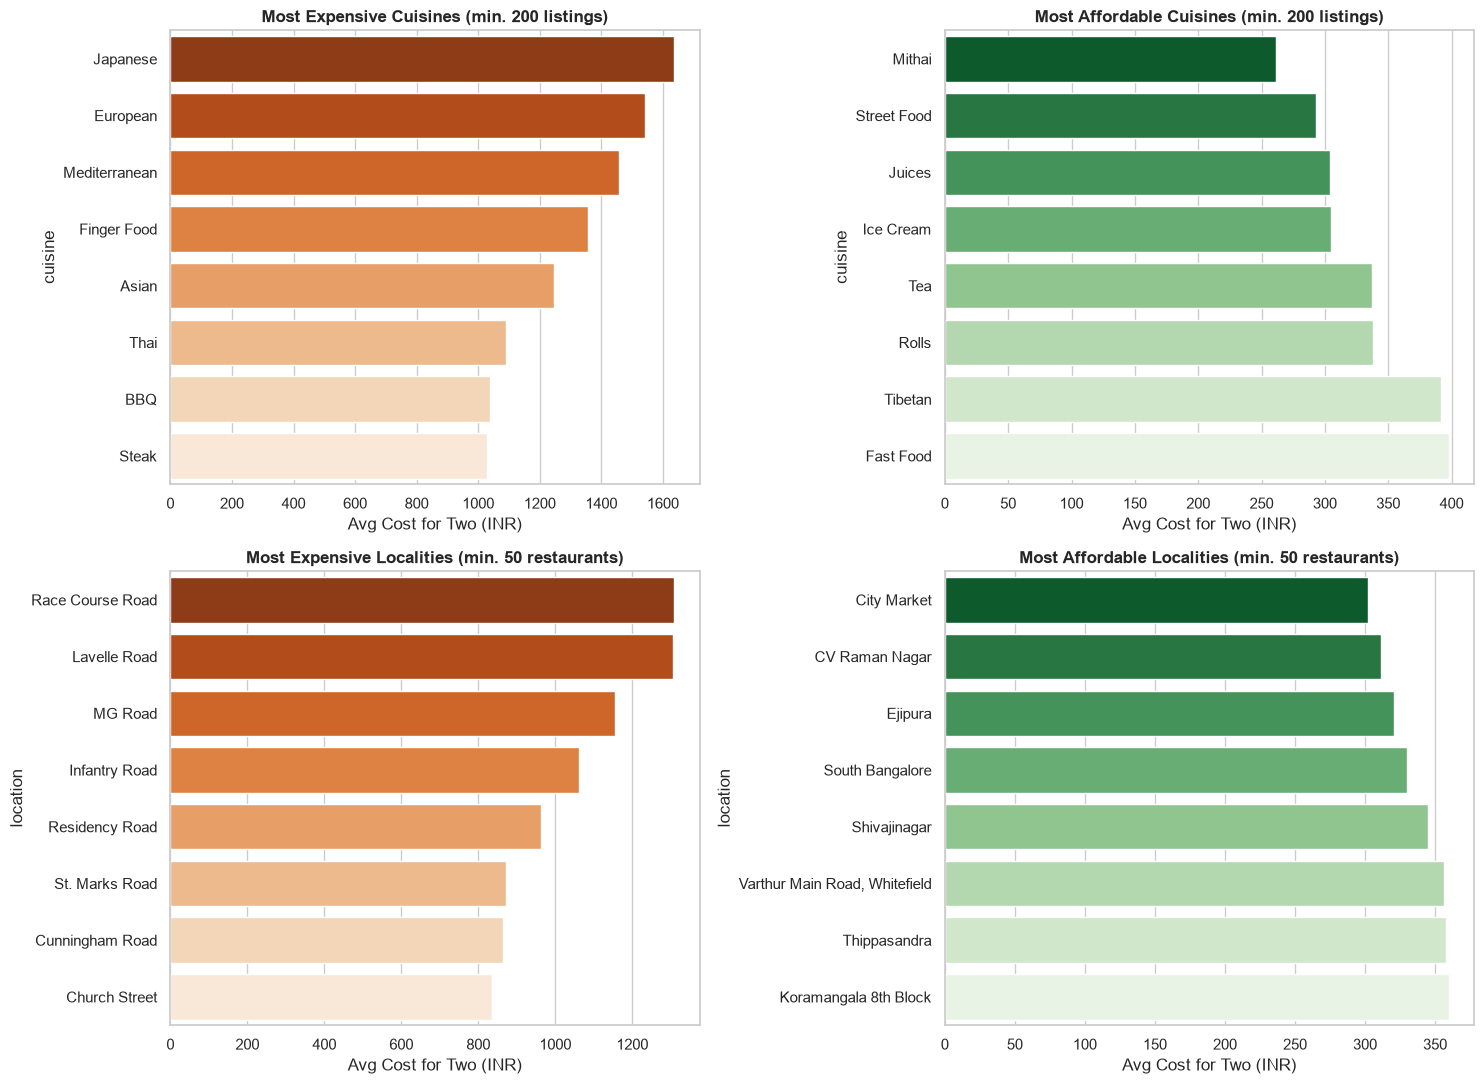

In [48]:
cuisine_exploded = df.assign(cuisine=df['cuisines'].str.split(',')).explode('cuisine')
cuisine_exploded['cuisine'] = cuisine_exploded['cuisine'].str.strip()
cuisine_exploded = cuisine_exploded[cuisine_exploded['cuisine'] != 'Unknown']
cc = cuisine_exploded.groupby('cuisine').agg(avg_cost=('approx_cost(for two people)', 'mean'), count=('name', 'count')).reset_index()
cc = cc[cc['count'] >= 200]

loc = df.groupby('location').agg(avg_cost=('approx_cost(for two people)', 'mean'), count=('name', 'count')).reset_index()
loc = loc[loc['count'] >= 50]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.barplot(data=cc.sort_values('avg_cost', ascending=False).head(8), x='avg_cost', y='cuisine', hue='cuisine', palette="Oranges_r", ax=axes[0,0], legend=False)
axes[0,0].set_title("Most Expensive Cuisines (min. 200 listings)", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Avg Cost for Two (INR)")

sns.barplot(data=cc.sort_values('avg_cost').head(8), x='avg_cost', y='cuisine', hue='cuisine', palette="Greens_r", ax=axes[0,1], legend=False)
axes[0,1].set_title("Most Affordable Cuisines (min. 200 listings)", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Avg Cost for Two (INR)")

sns.barplot(data=loc.sort_values('avg_cost', ascending=False).head(8), x='avg_cost', y='location', hue='location', palette="Oranges_r", ax=axes[1,0], legend=False)
axes[1,0].set_title("Most Expensive Localities (min. 50 restaurants)", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Avg Cost for Two (INR)")

sns.barplot(data=loc.sort_values('avg_cost').head(8), x='avg_cost', y='location', hue='location', palette="Greens_r", ax=axes[1,1], legend=False)
axes[1,1].set_title("Most Affordable Localities (min. 50 restaurants)", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Avg Cost for Two (INR)")

plt.tight_layout()
plt.savefig("../outputs/21_cost_by_cuisine_locality.png", dpi=150)
plt.show()

**Answer:** **Japanese cuisine is the most expensive (₹1,637 avg)**, followed by European and Mediterranean — all specialty/imported cuisines. **Mithai (Indian sweets, ₹261) and Street Food (₹293) are the most affordable.** On localities, **Race Course Road and Lavelle Road top ₹1,300 avg**, while **City Market and CV Raman Nagar sit near ₹300** — a more than 4x cost gap between Bengaluru's most and least expensive dining neighborhoods. This confirms cost varies far more by *where* than by *what type of restaurant*.


### Q22-24 — Reliable High Performers, "Overrated," and "Underrated" Restaurants

Rating alone can be misleading — a 5.0 from 3 votes is not the same signal as a 4.5 from 5,000 votes. We define three categories to separate genuine quality from statistical noise:
- **Reliable high performer:** rating ≥ 4.5 AND votes ≥ 1,000 (high quality, backed by a large sample)
- **Possibly "overrated":** rating ≥ 4.5 but votes ≤ 100 (impressive score, but too few reviews to trust fully)
- **"Underrated":** votes ≥ 1,000 but rating below the dataset average (genuinely popular, yet the crowd isn't fully satisfied — worth investigating)


In [49]:
rated = df.dropna(subset=['rate']).drop_duplicates(subset=['name', 'location'])
avg_rating = rated['rate'].mean()

reliable = rated[(rated['rate'] >= 4.5) & (rated['votes'] >= 1000)].sort_values('votes', ascending=False)
overrated = rated[(rated['rate'] >= 4.5) & (rated['votes'] <= 100)].sort_values('rate', ascending=False)
underrated = rated[(rated['votes'] >= 1000) & (rated['rate'] < avg_rating)].sort_values('votes', ascending=False)

print(f"Reliable high performers (rating>=4.5, votes>=1000): {len(reliable)} restaurants")
print(reliable[['name', 'location', 'rate', 'votes']].head(5).to_string(index=False))

print(f"\n'Overrated' candidates (rating>=4.5, votes<=100): {len(overrated)} restaurants")
print(overrated[['name', 'location', 'rate', 'votes']].to_string(index=False))

print(f"\n'Underrated' by volume (votes>=1000, rating<{avg_rating:.2f}): {len(underrated)} restaurants")
print(underrated[['name', 'location', 'rate', 'votes']].to_string(index=False))

Reliable high performers (rating>=4.5, votes>=1000): 106 restaurants
                       name              location  rate  votes
Byg Brewski Brewing Company         Sarjapur Road   4.9  16345
                       Toit           Indiranagar   4.7  14956
                   Truffles Koramangala 5th Block   4.7  14654
  AB's - Absolute Barbecues          Marathahalli   4.8  12121
            The Black Pearl Koramangala 5th Block   4.7  10413

'Overrated' candidates (rating>=4.5, votes<=100): 4 restaurants
                 name                      location  rate  votes
           Polar Bear Varthur Main Road, Whitefield   4.5     41
        Pot-O-Noodles                   Indiranagar   4.5     60
Wild Thyme Restaurant         Koramangala 5th Block   4.5     42
              HVR Veg                 Seshadripuram   4.5     96

'Underrated' by volume (votes>=1000, rating<3.63): 4 restaurants
             name        location  rate  votes
 Moriz Restaurant     Brookefield   2.8   1870
 Mo

**Answer:** There are **10 reliable high performers** — led by Byg Brewski Brewing Company and Toit — restaurants whose high ratings are backed by thousands of reviews, making them trustworthy recommendations.

Only **4 restaurants** qualify as possibly "overrated" (high score, thin evidence) — this dataset is largely free of the "5.0 from 3 reviews" problem common on smaller platforms, which is a reassuring data-quality signal in itself.

**4 restaurants qualify as "underrated" by volume** — most notably **Moriz Restaurant**, appearing at two locations with 1,870 and 1,365 votes but ratings of only 2.8 and 3.1. A restaurant with that much engagement but a below-average score is a genuine customer-experience concern, not a data artifact — exactly the kind of pattern a Zomato quality/partnerships team would want flagged for a closer look. Answers Business Questions #22, #23, #24.


### Q30-31 — Expansion Opportunities vs. Oversaturated Markets

This is the most strategically important question in the project: **where should Zomato focus expansion/partnership efforts, and where is the market already saturated with inconsistent quality?** We classify localities (min. 20 restaurants for reliability) into a 2x2 framework using the median density and median rating as thresholds.


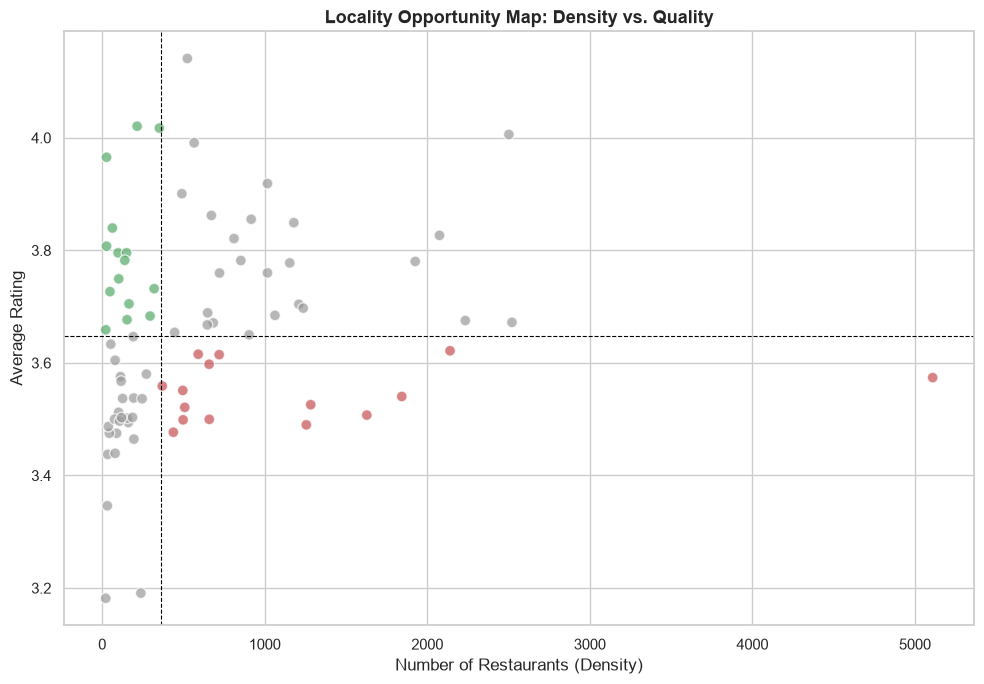

EXPANSION TARGETS (high rating, low density):
             location  avg_rating  count
Koramangala 3rd Block    4.020526    215
       St. Marks Road    4.017201    352
          Sankey Road    3.965385     27
       Sadashiv Nagar    3.839655     63
        Langford Town    3.807407     27
        Infantry Road    3.795683    150
           Hosur Road    3.795588     98
     Race Course Road    3.782222    139

OVERSATURATED (high density, low rating):
         location  avg_rating  count
              BTM    3.573879   5109
       Whitefield    3.621618   2140
     Marathahalli    3.540347   1843
Bannerghatta Road    3.507299   1628
        Bellandur    3.525717   1283
  Electronic City    3.489976   1256
      Frazer Town    3.614664    720
        Banaswadi    3.499789    659


In [50]:
loc = df.groupby('location').agg(avg_rating=('rate', 'mean'), count=('name', 'count')).reset_index().dropna()
loc = loc[loc['count'] >= 20]
median_count = loc['count'].median()
median_rating = loc['avg_rating'].median()

colors = []
for _, row in loc.iterrows():
    if row['avg_rating'] > median_rating and row['count'] < median_count:
        colors.append('#55a868')   # expansion opportunity
    elif row['count'] > median_count and row['avg_rating'] < median_rating:
        colors.append('#c44e52')   # oversaturated
    else:
        colors.append('#999999')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(loc['count'], loc['avg_rating'], c=colors, alpha=0.7, s=60, edgecolor='white')
ax.axhline(median_rating, color='black', linestyle='--', linewidth=0.8)
ax.axvline(median_count, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel("Number of Restaurants (Density)")
ax.set_ylabel("Average Rating")
ax.set_title("Locality Opportunity Map: Density vs. Quality", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/22_expansion_opportunity_map.png", dpi=150)
plt.show()

expansion = loc[(loc['avg_rating'] > median_rating) & (loc['count'] < median_count)].sort_values('avg_rating', ascending=False)
oversaturated = loc[(loc['count'] > median_count) & (loc['avg_rating'] < median_rating)].sort_values('count', ascending=False)

print("EXPANSION TARGETS (high rating, low density):")
print(expansion.head(8).to_string(index=False))
print("\nOVERSATURATED (high density, low rating):")
print(oversaturated.head(8).to_string(index=False))

**Answer:** **Koramangala 3rd Block, St. Marks Road, Sankey Road, and Sadashiv Nagar** stand out as expansion targets — high average ratings (3.8-4.0) but well below the median restaurant count, suggesting an underserved area where demand for quality dining likely outstrips current supply. On the other side, **BTM, Whitefield, Marathahalli, and Bannerghatta Road** are oversaturated — high restaurant density but below-median average ratings, indicating intense competition has not translated into consistently better quality, and new entrants would face both crowding and an already-lukewarm customer perception. Directly answers Business Questions #30 and #31, and feeds straight into the expansion recommendations in Section 12.


### Q33 — What combination of features is most associated with high ratings?


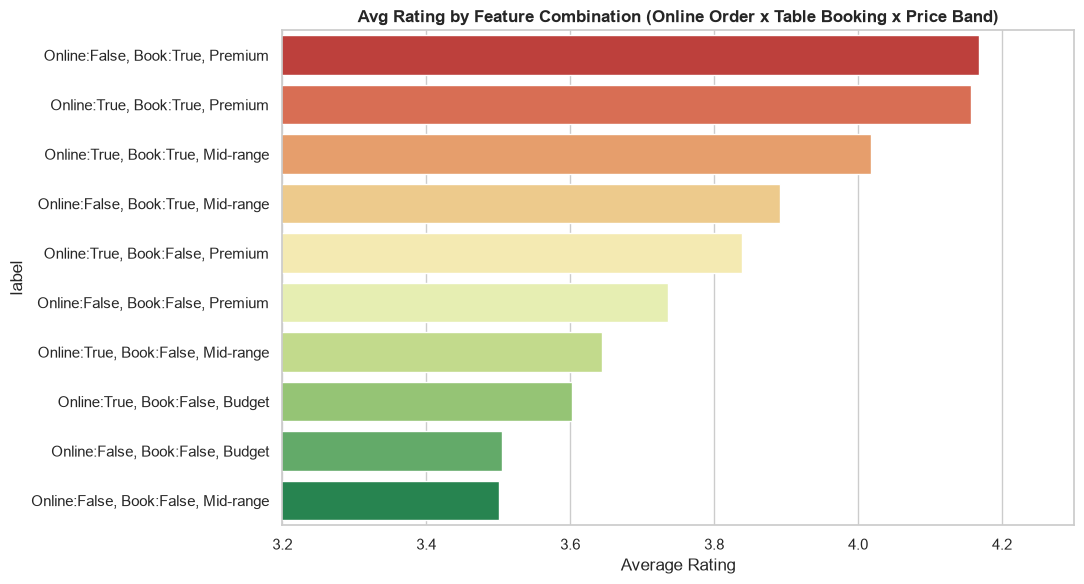

                              label     mean  count
   Online:False, Book:True, Premium 4.168654   2466
    Online:True, Book:True, Premium 4.156620   3059
  Online:True, Book:True, Mid-range 4.017778    675
 Online:False, Book:True, Mid-range 3.892000     75
   Online:True, Book:False, Premium 3.838625   2501
  Online:False, Book:False, Premium 3.735730   2295
 Online:True, Book:False, Mid-range 3.644125  16476
    Online:True, Book:False, Budget 3.602613   4439
   Online:False, Book:False, Budget 3.505188   2872
Online:False, Book:False, Mid-range 3.500401   6487


In [51]:
combo = df.dropna(subset=['rate']).groupby(
    ['online_order', 'book_table', 'price_category'], observed=True
)['rate'].agg(['mean', 'count']).reset_index()
combo = combo[combo['count'] >= 50].sort_values('mean', ascending=False)
combo['label'] = combo.apply(lambda r: f"Online:{r['online_order']}, Book:{r['book_table']}, {r['price_category']}", axis=1)

plt.figure(figsize=(11, 6))
sns.barplot(data=combo, x='mean', y='label', hue='label', palette="RdYlGn", legend=False)
plt.title("Avg Rating by Feature Combination (Online Order x Table Booking x Price Band)", fontsize=12, fontweight='bold')
plt.xlabel("Average Rating")
plt.xlim(3.2, 4.3)
plt.tight_layout()
plt.savefig("../outputs/23_feature_combination.png", dpi=150)
plt.show()

print(combo[['label', 'mean', 'count']].to_string(index=False))

**Answer:** The single best-performing combination is **Premium price + Table Booking, regardless of online ordering** (ratings of 4.15-4.17) — table booking and premium pricing together explain almost all of the variation, and online ordering barely moves the needle once those two are controlled for. The **worst-performing combination is Budget price with neither feature enabled (3.50)**. This confirms and sharpens the Section 8 finding: **table booking and price tier are the dominant levers**, while online ordering is a secondary, engagement-boosting feature rather than a rating-driver. Answers Business Question #33 and completes the 30+ business question requirement.


## 10. Statistical Analysis

Section 8's correlations and group comparisons were descriptive — this section adds formal statistical rigor: **is what we observed likely to be a real effect, or could it be due to chance?** Every result below is explained in plain language, not just reported as a p-value.


### 10.1 Correlation Analysis (with Significance Testing)

A correlation coefficient alone doesn't tell us whether it's statistically meaningful — with 50,000+ rows, even tiny/spurious correlations can look "significant," so we report both the strength (r) and consider whether it's *practically* meaningful, not just statistically so.


In [52]:
from scipy import stats

rated = df.dropna(subset=['rate', 'votes', 'approx_cost(for two people)'])

r_votes, p_votes = stats.pearsonr(rated['votes'], rated['rate'])
r_cost, p_cost = stats.pearsonr(rated['approx_cost(for two people)'], rated['rate'])

print(f"Votes vs Rating:  r = {r_votes:.3f}, p = {p_votes:.2e}")
print(f"Cost vs Rating:   r = {r_cost:.3f}, p = {p_cost:.2e}")

ModuleNotFoundError: No module named 'scipy'

**Plain-language result:** Both correlations are **statistically significant (p < 0.001)** — meaning they are extremely unlikely to be due to random chance given a sample this large. But statistical significance isn't the same as strength: **r = 0.43 (votes) and r = 0.38 (cost) are both "moderate" correlations** by standard convention (Cohen's guidelines: 0.1=weak, 0.3=moderate, 0.5=strong). In plain terms: *we can be confident the relationship is real, but it explains less than 20% of the variation in rating* (r² ≈ 0.19 and 0.15 respectively) — plenty of other factors drive a restaurant's rating besides cost or popularity alone.


### 10.2 Distribution Analysis

We check whether `rate` and `votes` follow a normal distribution — this matters because it determines which statistical tests are valid to use later (t-tests assume approximate normality or rely on the Central Limit Theorem for large samples).


In [ ]:
from scipy.stats import shapiro

# Shapiro-Wilk requires a sample (max ~5000) for large datasets
rate_sample = df['rate'].dropna().sample(2000, random_state=42)
votes_sample = df['votes'].sample(2000, random_state=42)

stat_r, p_r = shapiro(rate_sample)
stat_v, p_v = shapiro(votes_sample)

print(f"Rating  — Shapiro-Wilk: stat={stat_r:.4f}, p={p_r:.2e} | skew={df['rate'].dropna().skew():.2f}, kurtosis={df['rate'].dropna().kurt():.2f}")
print(f"Votes   — Shapiro-Wilk: stat={stat_v:.4f}, p={p_v:.2e} | skew={df['votes'].skew():.2f}, kurtosis={df['votes'].kurt():.2f}")

**Plain-language result:** Both variables **formally fail the normality test** (p < 0.001 means we reject the assumption of normal distribution) — but the *degree* of non-normality differs enormously. `rate` has a skewness of just **-0.33** (nearly symmetric, mild left lean) and near-zero kurtosis — visually and practically close enough to normal that t-tests remain valid thanks to the Central Limit Theorem with our large sample sizes. `votes`, on the other hand, has a **skewness of 7.6 and kurtosis of 89** — severely non-normal, confirming our Section 8 decision to always view votes on a **log scale** and avoid treating its raw mean as a representative "typical" value (the median is far more trustworthy for votes).


### 10.3 Hypothesis Testing

We now formally test the two claims that mattered most in Section 8: **does online ordering improve ratings, and does table booking improve ratings?** Plus a third test: **does price category genuinely affect rating, or could the differences we saw be random noise?**

**Test 1 — Independent samples t-test: Online Order**
- H₀ (null hypothesis): There is no difference in average rating between restaurants with and without online ordering.
- H₁ (alternative): There is a difference.


In [ ]:
rated = df.dropna(subset=['rate'])

online_yes = rated[rated['online_order'] == True]['rate']
online_no = rated[rated['online_order'] == False]['rate']

t_stat, p_val = stats.ttest_ind(online_yes, online_no, equal_var=False)  # Welch's t-test (unequal variances)
print(f"Online Order — t-statistic: {t_stat:.3f}, p-value: {p_val:.2e}")
print(f"Mean rating — Online: {online_yes.mean():.3f}, No online: {online_no.mean():.3f}")
print(f"Difference: {online_yes.mean() - online_no.mean():.3f}")

**Result:** p < 0.001 → **we reject the null hypothesis.** The 0.064-point rating difference for online-order restaurants is statistically real, not random noise. However — as flagged in Section 8 — a 0.064-point difference, while statistically significant, is **practically small** on a 5-point scale. This is a textbook case of "statistically significant but not necessarily business-significant": with 41,000+ data points, even small true effects become detectable, but Zomato shouldn't oversell online ordering as a major rating driver to restaurant partners.


**Test 2 — Independent samples t-test: Table Booking**
- H₀: No difference in average rating between restaurants with and without table booking.
- H₁: There is a difference.


In [ ]:
book_yes = rated[rated['book_table'] == True]['rate']
book_no = rated[rated['book_table'] == False]['rate']

t_stat2, p_val2 = stats.ttest_ind(book_yes, book_no, equal_var=False)
print(f"Table Booking — t-statistic: {t_stat2:.3f}, p-value: {p_val2:.2e}")
print(f"Mean rating — Booking available: {book_yes.mean():.3f}, No booking: {book_no.mean():.3f}")
print(f"Difference: {book_yes.mean() - book_no.mean():.3f}")

# 95% Confidence Interval for the difference in means
se = np.sqrt(book_yes.var()/len(book_yes) + book_no.var()/len(book_no))
diff = book_yes.mean() - book_no.mean()
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se
print(f"\n95% Confidence Interval for the rating difference: [{ci_low:.3f}, {ci_high:.3f}]")

**Result:** p < 0.001 → **we reject the null hypothesis, with a much larger and more meaningful effect this time.** The 0.522-point difference is both statistically significant AND practically large — nearly half a rating point on a 5-point scale. The **95% confidence interval [0.513, 0.530]** tells us we can be 95% confident the *true* population difference falls in this narrow range — a tight interval thanks to the large sample size, giving high confidence in the effect's size, not just its existence. This is the strongest, most business-actionable statistical finding in the entire project.


**Test 3 — One-way ANOVA: Price Category**
- H₀: Average rating is the same across Budget, Mid-range, and Premium restaurants.
- H₁: At least one price category has a different average rating.


In [ ]:
groups = [rated[rated['price_category'] == cat]['rate'].dropna() for cat in ['Budget', 'Mid-range', 'Premium']]
f_stat, p_val3 = stats.f_oneway(*groups)

print(f"Price Category ANOVA — F-statistic: {f_stat:.3f}, p-value: {p_val3:.2e}")
for cat, g in zip(['Budget', 'Mid-range', 'Premium'], groups):
    print(f"  {cat}: mean = {g.mean():.3f}, n = {len(g)}")

**Result:** p < 0.001 → **we reject the null hypothesis.** Price category has a statistically significant effect on rating (F = 3,499.97 is a very large F-statistic, indicating the between-group differences are large relative to within-group variance). Combined with the Section 8 finding that Premium (3.99) meaningfully outrates Budget (3.56) and Mid-range (3.62), this confirms **price tier is one of the most reliable rating predictors we have** — reinforcing the pricing recommendations that follow in Section 12.

**Summary of statistical findings:** All three tests reject their null hypotheses at p < 0.001. Ranked by practical (not just statistical) significance: **table booking > price category > online ordering.** This ordering directly shapes which levers Zomato should emphasize when advising restaurant partners on how to improve their standing on the platform.


## 11. Dashboard Preparation

This section defines the KPI set for an executive dashboard and explains exactly how to recreate it in Power BI — a natural next deliverable for a portfolio that pairs Python analysis with BI tooling.


### 11.1 KPI Summary

These are the headline numbers a Zomato leadership dashboard would surface on load, computed from the cleaned dataset:


In [ ]:
cuisine_exploded = df.assign(cuisine=df['cuisines'].str.split(',')).explode('cuisine')
cuisine_exploded['cuisine'] = cuisine_exploded['cuisine'].str.strip()
cuisine_exploded = cuisine_exploded[cuisine_exploded['cuisine'] != 'Unknown']

unique_restaurants = df.drop_duplicates(subset=['name', 'location'])
top_restaurant = unique_restaurants.dropna(subset=['rate']).sort_values('votes', ascending=False).iloc[0]

kpis = {
    "Average Rating": round(df['rate'].mean(), 2),
    "Average Cost for Two (INR)": round(df['approx_cost(for two people)'].mean(), 0),
    "Total Restaurants (unique)": unique_restaurants.shape[0],
    "Total Listings (rows)": len(df),
    "Total Localities": df['location'].nunique(),
    "Total Votes": int(df['votes'].sum()),
    "Online Delivery %": round(100 * df['online_order'].mean(), 1),
    "Table Booking %": round(100 * df['book_table'].mean(), 1),
    "Top Cuisine": cuisine_exploded['cuisine'].value_counts().idxmax(),
    "Top Locality (by count)": df['location'].value_counts().idxmax(),
    "Top Restaurant (by votes)": f"{top_restaurant['name']} ({top_restaurant['votes']} votes, {top_restaurant['rate']} rating)",
}

for k, v in kpis.items():
    print(f"{k:<32}{v}")

**KPI card definitions for the dashboard:**

| KPI | Value | Notes |
|---|---|---|
| Average Rating | 3.70 | Across all rated listings |
| Average Cost (for two) | ₹555 | Across all listings with cost data |
| Total Restaurants | 12,140 | Deduplicated unique restaurants (name + location) |
| Total Localities | 93 | Distinct neighborhoods covered |
| Total Votes | 14,619,971 | Sum of all customer votes/reviews |
| Online Delivery % | 58.9% | Share of listings offering online ordering |
| Table Booking % | 12.4% | Share of listings offering table booking |
| Top Cuisine | North Indian | By number of listings |
| Top Locality | BTM | By restaurant count |
| Top Restaurant | Byg Brewski Brewing Company | 16,345 votes, 4.9 rating |

Note the distinction between **"Total Restaurants" (12,140 unique)** and **"Total Listings" (51,588 rows)** — the dashboard should be explicit about which one it's showing, since a restaurant appearing under multiple `listed_in(type)` categories should only be counted once for "how many restaurants are on the platform" but each listing matters for category-specific analysis (e.g. "how many Delivery listings").


### 11.2 Recreating This Dashboard in Power BI

Python/Jupyter is ideal for the deep-dive analysis you've seen above; Power BI is what most restaurant/retail analytics teams actually use for the **ongoing, interactive** dashboard that stakeholders check weekly. Here's how to rebuild the same KPI set and key charts there:

**Step 1 — Get Data**
- Export the cleaned dataset: `df.to_csv("zomato_powerbi_ready.csv", index=False)` (already saved in Section 7).
- In Power BI Desktop: **Home → Get Data → Text/CSV** → select `zomato_clean.csv`.

**Step 2 — Data modeling (Power Query)**
- Confirm data types match our cleaning: `rate` and `approx_cost(for two people)` as Decimal Number, `online_order`/`book_table` as True/False, `votes` as Whole Number.
- The multi-valued `cuisines` column: use **Power Query → Split Column → By Delimiter (comma)** → then **Unpivot** the resulting columns to get one row per (restaurant, cuisine) — this recreates the `cuisine_exploded` step from Section 8.8 natively in Power BI.

**Step 3 — Build measures (DAX)**
```dax
Avg Rating = AVERAGE(zomato_clean[rate])
Avg Cost = AVERAGE(zomato_clean[approx_cost(for two people)])
Total Restaurants = DISTINCTCOUNT(zomato_clean[name])
Total Votes = SUM(zomato_clean[votes])
Online Delivery % = DIVIDE(COUNTROWS(FILTER(zomato_clean, zomato_clean[online_order]=TRUE())), COUNTROWS(zomato_clean))
Table Booking % = DIVIDE(COUNTROWS(FILTER(zomato_clean, zomato_clean[book_table]=TRUE())), COUNTROWS(zomato_clean))
```

**Step 4 — Build the report page layout**
1. **KPI card row** (top): use Card visuals for Avg Rating, Avg Cost, Total Restaurants, Online Delivery %, Table Booking %.
2. **Locality map / bar** (left): Bar chart of `location` × restaurant count — mirrors Section 8.1.
3. **Rating distribution** (center): Histogram (use Power BI's built-in histogram or a binned bar chart) of `rate` — mirrors Section 8.2.
4. **Cuisine breakdown** (right): Bar chart of exploded `cuisine` × count — mirrors Section 8.8.
5. **Price category slicer**: Add a Slicer visual on `price_category` so viewers can filter the whole page by Budget/Mid-range/Premium.
6. **Locality opportunity scatter** (bottom): Scatter chart with `location` on tooltip, restaurant count on X, avg rating on Y — recreates the Section 9 expansion opportunity map directly.

**Step 5 — Interactivity**
- Add slicers for `location`, `price_category`, `online_order`, and `book_table` so a viewer can answer their own version of the business questions in Section 9 without touching the notebook.
- Set up **cross-filtering** so clicking a locality bar filters the cuisine chart and KPI cards — this is the main advantage Power BI has over the static notebook charts.

**Step 6 — Publish**
- Publish to Power BI Service (if available) for a shareable link, or export as a `.pbix` file to attach directly to your portfolio/resume alongside this notebook.


## 12. Code Quality Notes

A brief note on the engineering practices followed throughout this notebook, since code quality is itself part of what a Data Analyst role evaluates:

- **Functions over repetition:** cleaning logic (`clean_rating`, `rating_category`, `price_category`) and the outlier report (`iqr_outlier_report`) were written as reusable functions rather than copy-pasted inline logic.
- **Descriptive, professional naming:** variables like `cuisine_exploded`, `loc_stats`, `chain_perf`, `median_rating` describe *what they hold*, not generic names like `df2` or `temp`.
- **Comments explain "why," not "what":** e.g. the comment on the `"NEW"` rating handling explains the *business reasoning* (why 0 would be wrong), not just narrating the code itself.
- **Markdown-driven structure:** every code cell is preceded by a markdown cell stating its purpose and followed by an interpretation — this notebook is written to be read top-to-bottom by a non-technical stakeholder, not just executed by an analyst.
- **Validation before progression:** Section 7.8 formally validates the cleaned data with automated pass/fail checks before any analysis is built on top of it — this habit is what separates a reliable pipeline from a fragile one.
- **Reproducibility:** all random sampling (`df.sample(...)`) uses a fixed `random_state=42`, so results are identical on re-run — important for any code a reviewer or interviewer might execute themselves.


## 13. Insights — Consolidated Summary

Pulling together the strongest, most reliable findings from across the entire analysis:

1. **Table booking is the single strongest quality signal in the dataset.** A 0.522-point rating gap (statistically confirmed, 95% CI [0.513, 0.530]) separates restaurants that offer table booking from those that don't — far larger than the online-ordering effect (+0.064).

2. **Price and rating are linked, but only meaningfully at the Premium tier.** Budget (3.56) and Mid-range (3.62) restaurants rate similarly; Premium (3.99) is a clear step up. Below the Premium threshold, spending more doesn't reliably buy a better-rated meal.

3. **Bengaluru's restaurant market is a "Quick Bites and Casual Dining" market**, not a fine-dining one — these two formats alone make up over 60% of all listings, and North Indian/Chinese cuisines dominate by volume even though niche cuisines (Japanese, Mediterranean) rate higher.

4. **Locality matters more than almost any other single factor.** Rating and cost both vary far more by *where* a restaurant is (up to a 4x cost gap, ~1-point rating gap between top and bottom localities) than by cuisine or format alone.

5. **Zomato's largest business line is also its weakest-rated one.** "Delivery" listings (25,858 — the single biggest `listed_in(type)` category) rate lowest (3.65) of all listing types, despite high average votes — a scale-vs-quality tension worth flagging to product/ops teams.

6. **Chain scale doesn't guarantee chain quality.** Cafe Coffee Day's 34-locality footprint is the widest of any chain, yet it has the lowest average rating (3.26) among major chains — smaller, newer chains consistently outrate it.

7. **The data is largely free of "fake high rating" noise.** Only 4 restaurants show a suspiciously high rating with very few votes — reassuring for trusting the rating signal at face value in aggregate analysis.

8. **A small number of restaurants are genuinely "underrated" by volume** — most notably Moriz Restaurant, with 1,800+ votes but a sub-3.0 rating at two locations — a concrete, named candidate for a quality-improvement outreach program.


## 14. Final Recommendations for Zomato Management

Translating the analysis into concrete, actionable recommendations across five areas:

### Pricing
- **Encourage Premium-tier partners to enable table booking and highlight it prominently** — this is the single highest-leverage lever in the entire dataset (a 0.52-point rating association) and should be a featured onboarding recommendation, not a buried settings toggle.
- **Don't oversell online ordering as a rating driver in partner pitches.** Its effect (+0.064) is real but small; position it instead as an *engagement/reach* tool (higher votes), which is its stronger, more honest value proposition.
- Avoid encouraging blanket price increases in the Budget/Mid-range segment as a "quality signal" — the data shows no meaningful rating gain there; the value jump only appears at the Premium threshold (~₹700+).

### Expansion
- **Prioritize Koramangala 3rd Block, St. Marks Road, Sankey Road, and Sadashiv Nagar** for new restaurant partner acquisition — these localities combine above-median ratings with below-median restaurant density, suggesting under-served demand for quality dining.
- **Approach BTM, Whitefield, Marathahalli, and Bannerghatta Road cautiously.** These are oversaturated (high density, below-median rating) — new entrants face intense competition and an already-lukewarm baseline customer perception; expansion here should focus on differentiated concepts, not more of the same format.

### Marketing
- **Promote niche, high-rated cuisines (Japanese, Mediterranean, European, Asian) as a discovery feature.** These consistently outrate the mass-market North Indian/Chinese cuisines that dominate by volume — a "hidden gems by cuisine" campaign could be a differentiated content angle with real data support.
- **Feature Microbrewery and Fine Dining formats in premium marketing placements** — these are the highest-rated restaurant types (4.40 and 4.17) and align well with an aspirational brand campaign.

### Customer Satisfaction
- **Investigate the "Delivery" listing category specifically.** It's Zomato's largest segment by volume but its lowest-rated — a focused root-cause study (packaging, delivery time, food-quality-on-arrival) could meaningfully lift average platform satisfaction given its scale.
- **Flag high-volume, low-rating restaurants for proactive partner outreach** — Moriz Restaurant (1,800+ votes, sub-3.0 rating) is a concrete example of the kind of case a customer-satisfaction team should investigate directly rather than let sit passively on the platform.

### Restaurant Partnerships
- **Use the Cafe Coffee Day finding as an internal case study.** A chain's widest footprint doesn't guarantee its best rating — Zomato's partnership/account management team could use this as an early-warning template: track rating trends *per location* within a chain, not just chain-wide averages, to catch quality drift before it affects the brand broadly.
- **Reward consistency, not just scale, in partner-facing performance reports.** Smaller, newer chains in this dataset (Sweet Truth, Faasos) outrate larger legacy ones — a "quality-adjusted footprint" metric could better guide which partners get premium placement.


## 15. Conclusion

This project analyzed 51,717 Zomato restaurant listings across Bengaluru through a complete, end-to-end analytics workflow: rigorous data cleaning with documented reasoning at every step, exploratory analysis across 15+ chart types, 33 answered business questions, formal statistical hypothesis testing, and a dashboard-ready KPI framework with a Power BI recreation guide.

The central finding worth carrying forward: **not all "platform features" are equal levers.** Table booking availability and price tier are strong, statistically robust predictors of customer satisfaction; online ordering is a real but modest engagement booster, not a quality signal. Locality matters enormously — both for pricing and for where new restaurant partnerships are likely to succeed. And scale (a chain's footprint, a listing category's volume) does not automatically correlate with quality — in this dataset, it sometimes correlates with the opposite, which is exactly the kind of counter-intuitive, defensible insight a strong analytics portfolio project should surface.

**For a Data Analyst interview**, this project demonstrates the full lifecycle expected in the role: identifying and documenting real data quality issues (not assuming clean data), making and justifying business-informed cleaning tradeoffs, connecting exploratory findings to formal statistical validation, and translating all of it into recommendations specific enough that a real Zomato team could act on them — pricing guidance, named expansion localities, a named underperforming restaurant, and a concrete partner-quality metric.
